# k 近邻（kNN）练习

*请将这份完整的练习表（包括所有输出结果以及表格外部的支持代码）随本次作业一并提交。更多详情见课程官网的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

kNN 分类器包含两个阶段：

- **训练阶段**：分类器仅读取并“记忆”所有训练数据，不做额外计算。  
- **测试阶段**：对每张测试图像，kNN 将其与所有训练图像逐一比较，找出最相似的 k 张训练图像，并将这 k 张图像中出现次数最多的标签赋给测试图像。  
- **k 值的选择**通过交叉验证确定。

在本练习中，你将实现上述步骤，借此掌握图像分类的基本流程，理解交叉验证，并提高编写高效、向量化代码的能力。

In [9]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 运行本 notebook 所需的初始化代码

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10   # 加载 CIFAR-10 数据的工具函数
import matplotlib.pyplot as plt

# 让 matplotlib 图形直接嵌入在 notebook 中，而不是弹出新窗口
%matplotlib inline
# 统一设置图片默认大小，便于查看
plt.rcParams['figure.figsize'] = (10.0, 8.0)
# 关闭插值，使像素边界更清晰
plt.rcParams['image.interpolation'] = 'nearest'
# 灰度图默认使用灰度色图
plt.rcParams['image.cmap'] = 'gray'

# 开启 IPython 的自动重载功能：修改外部 .py 文件后无需重启 kernel 即可生效
# 官方讨论贴地址：http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# 注意：由于网络原因，上述链接暂时无法成功解析。如果你需要查看该网页内容，
# 请检查链接是否有效，或稍后重试；若不需要查看，可直接继续后续操作。
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# 加载原始 CIFAR-10 数据
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# 如果之前已加载过数据，先删除相关变量，防止重复加载导致内存占用过高
try:
    del X_train, y_train
    del X_test, y_test
    print('已清空之前加载的数据。')
except:
    pass

# 真正从磁盘读取 CIFAR-10
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 简单检查：打印训练集和测试集的形状
print('训练数据形状: ', X_train.shape)
print('训练标签形状: ', y_train.shape)
print('测试数据形状: ', X_test.shape)
print('测试标签形状: ', y_test.shape)

训练数据形状:  (50000, 32, 32, 3)
训练标签形状:  (50000,)
测试数据形状:  (10000, 32, 32, 3)
测试标签形状:  (10000,)


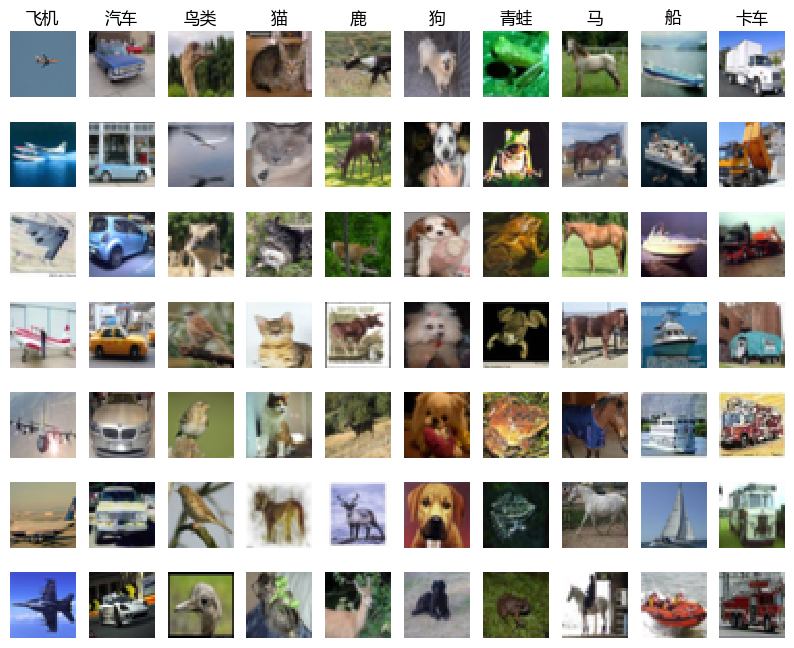

In [10]:
# 可视化数据集中的一些样本
# 从每个类别中随机展示若干张训练图像

classes = ['飞机', '汽车', '鸟类', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']
num_classes = len(classes)              # 类别数（10）
samples_per_class = 7                   # 每类展示 7 张图

for y, cls in enumerate(classes):
    # 找到所有属于当前类别的训练样本索引
    idxs = np.flatnonzero(y_train == y)
    # 随机选择 7 张且不重复
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    
    for i, idx in enumerate(idxs):
        # 计算子图位置
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        # 显示图像
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        # 只在第一行写类别名
        if i == 0:
            plt.title(cls)

plt.show()

In [11]:
# 为了在本练习中更高效地运行代码，对数据进行子采样
num_training = 5000          # 仅保留前 5000 张训练图像
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500               # 仅保留前 500 张测试图像
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# 将图像数据展平成行向量（每行代表一张图像的所有像素）
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  -1))

# 打印处理后的数据形状
print('训练数据形状:', X_train.shape)
print('测试数据形状:', X_test.shape)

训练数据形状: (5000, 3072)
测试数据形状: (500, 3072)


In [13]:
# 从 cs231n.classifiers 中导入 k 近邻分类器
from cs231n.classifiers import KNearestNeighbor

# 创建 kNN 分类器实例
# 注意：训练 kNN 分类器实际上什么都不做（no-op）：
# 分类器只是把训练数据“记住”，不会进行任何额外处理
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)  # 仅保存训练数据

现在我们希望用 kNN 分类器对测试数据进行分类。  
整个过程可以拆成两步：

1. **计算所有测试样本与所有训练样本之间的距离**  
   如果有 **Ntr** 个训练样本和 **Nte** 个测试样本，这一步应得到一个 **Nte × Ntr** 的距离矩阵，其中元素 (i, j) 表示第 i 个测试样本与第 j 个训练样本之间的距离。

2. **根据距离矩阵，对每个测试样本找出最近的 k 个训练样本，并通过投票决定其标签**

首先从计算距离矩阵开始。  
**注意：本 notebook 中要求你实现的三种距离计算方法均不得使用 Numpy 提供的 `np.linalg.norm()`。**

请先打开 `cs231n/classifiers/k_nearest_neighbor.py`，在 `compute_distances_two_loops` 函数中用**双重显式循环**（非常低效）逐个计算所有 (测试, 训练) 样本对的距离。

In [14]:
# 打开文件 cs231n/classifiers/k_nearest_neighbor.py
# 在文件中实现 compute_distances_two_loops 函数

# 测试你的实现：
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)  # 应输出 (500, 5000)，即 500 个测试样本与 5000 个训练样本的距离矩阵

(500, 5000)


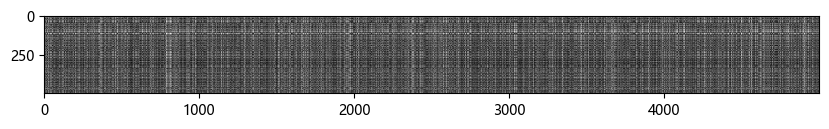

In [26]:
# 可视化距离矩阵：矩阵的每一行对应一个测试样本
# 行中的每个像素值表示该测试样本与所有训练样本之间的距离
plt.imshow(dists, interpolation='none')
plt.show()

**内联问题 1**

在距离矩阵中可以观察到明显的结构性模式：某些行或列看起来明显更亮。（默认配色下，黑色表示距离小，白色表示距离大。）

- 造成这些**明显更亮的行**的原因是什么？
- 造成这些**明显更亮的列**的原因是什么？

$\color{blue}{\textit 你的答案：}$

更亮的行：一行对应单个测试样本，整行偏亮代表：该测试样本和全部训练样本的 L2 距离整体偏大，图片内容特征和整个训练数据集普遍差异大，和绝大多数训练图片都不相似。

更亮的列：一列对应单个训练样本，整列偏亮代表：该训练样本和全部测试样本的 L2 距离整体偏大，这张训练图片的特征和绝大多数测试图片都差异明显。



In [22]:
# 现在实现 predict_labels 函数，并运行下方代码
# 这里取 k = 1，即最近邻（Nearest Neighbor）
y_test_pred = classifier.predict_labels(dists, k=1)

# 计算并打印预测正确的比例
num_correct = np.sum(y_test_pred == y_test)  # 正确预测的样本数
accuracy = float(num_correct) / num_test     # 准确率
print('预测正确 %d / %d 个样本 => 准确率: %f' % (num_correct, num_test, accuracy))

预测正确 137 / 500 个样本 => 准确率: 0.274000


你应该会看到大约 `27%` 的准确率。  
现在我们尝试更大的 `k`，设 `k = 5`：

In [25]:
# 使用 k=5 重新预测
y_test_pred = classifier.predict_labels(dists, k=5)

# 计算正确预测数量
num_correct = np.sum(y_test_pred == y_test)

# 计算准确率
accuracy = float(num_correct) / num_test
print('预测正确 %d / %d 个样本 => 准确率: %f' % (num_correct, num_test, accuracy))

预测正确 139 / 500 个样本 => 准确率: 0.278000


你应该会看到准确率比 `k = 1` 时略有提升。

**内联问题 2**

我们也可以使用其他距离度量，例如 L1 距离。  
记图像 $I_k$ 在位置 $(i,j)$ 处的像素值为 $p_{ij}^{(k)}$，

所有像素在所有图像上的全局均值为  
$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$  

每个像素在所有图像上的像素级均值为  
$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}$  

类似地可定义全局标准差 $\sigma$ 和像素级标准差 $\sigma_{ij}$。

对于使用 L1 距离的最近邻分类器，下列哪些预处理步骤**不会改变其性能**？（可多选）  
注意：训练集和测试集均采用完全相同的预处理方式。

1. 减去全局均值 $\mu$（$\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$）。
2. 减去像素级均值 $\mu_{ij}$（$\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$）。
3. 先减去全局均值 $\mu$，再除以全局标准差 $\sigma$。
4. 先减去像素级均值 $\mu_{ij}$，再除以像素级标准差 $\sigma_{ij}$。
5. 将数据的坐标轴整体旋转，即把所有图像按同一角度旋转。旋转造成的图像空白区域用同一像素值填充，且不做插值。

$\color{blue}{\textit{你的答案：}}$

1、2 不会改变 L1-kNN 性能；3、4、5 会改变性能

$\color{blue}{\textit{你的解释：}}$

1. 减去全局均值$\mu$,不改变性能

- $\tilde x=x-\mu,\ \tilde y=y-\mu$

- $\sum|\tilde x-\tilde y|=\sum|(x-\mu)-(y-\mu)|=\sum|x-y|$

- L1 距离完全不变 → 近邻排序不变，分类结果不变。

2. 减去像素级均值$\mu_{ij}$,不改变性能
- 每个维度单独减常数：$\tilde x_d=x_d-\mu_d,\ \tilde y_d=y_d-\mu_d$
- $\sum|\tilde x_d-\tilde y_d|=\sum|(x_d-\mu_d)-(y_d-\mu_d)|=\sum|x_d-y_d|$
- L1 距离完全不变 → 近邻排序不变，分类结果不变。

3. 先减去全局均值 $\mu$，再除以全局标准差 $\sigma$，会改变性能
- $\tilde x=\frac{x-\mu}{\sigma}$，$\sigma$是全局常数：
- $\sum\left|\frac{x-\mu}{\sigma}-\frac{y-\mu}{\sigma}\right|=\frac1\sigma\sum|x-y|$
- 全局统一缩放所有维度，距离等比例缩放，近邻顺序不变

4. 先减去像素级均值 $\mu_{ij}$，再除以像素级标准差 $\sigma_{ij}$，会改变性能
- 逐维除以各自$\sigma_{ij}$，每个维度缩放系数不一样：
- $\tilde x_d=\frac{x_d-\mu_d}{\sigma_d},\ \tilde y_d=\frac{y_d-\mu_d}{\sigma_d}$
- $\sum\left|\frac{x_d-y_d}{\sigma_d}\right|\neq \frac1C\sum|x_d-y_d|$
- 各维度权重被改变，L1 距离的相对大小发生变化，近邻排序改变

5. 将数据的坐标轴整体旋转，即把所有图像按同一角度旋转，旋转造成的图像空白区域用同一像素值填充，且不做插值，会改变性能
- 旋转改变了图像的空间结构，导致像素值位置发生变化，L1 距离的计算结果发生变化，近邻排序改变

In [27]:
# 现在用“部分向量化 + 单循环”来加速距离矩阵的计算。
# 请在 k_nearest_neighbor.py 中实现 compute_distances_one_loop 函数，然后运行下方代码：
dists_one = classifier.compute_distances_one_loop(X_test)

# 为确保向量化实现正确，我们将其与朴素实现进行比较。
# 判断两个矩阵是否一致的最简单方法之一是 Frobenius 范数。
# Frobenius 范数：把两个矩阵拉平成向量后，计算它们的欧氏距离
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('单循环实现与朴素实现的差异: %f' % difference)
if difference < 0.001:
    print('很好！两个距离矩阵完全一致。')
else:
    print('警告！两个距离矩阵不相同。')

单循环实现与朴素实现的差异: 0.000000
很好！两个距离矩阵完全一致。


In [28]:
# 现在请在 compute_distances_no_loops 中实现完全向量化的版本，
# 并运行以下代码：
dists_two = classifier.compute_distances_no_loops(X_test)

# 检查新的距离矩阵与之前计算的是否一致：
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('无循环差异：%.6f' % difference)
if difference < 0.001:
    print('很好！两个距离矩阵完全一致。')
else:
    print('警告！两个距离矩阵不相同。')

无循环差异：0.000000
很好！两个距离矩阵完全一致。


In [29]:
# 比较不同实现的运行速度
def time_function(f, *args):
    """
    调用函数 f 并传入参数 args，返回函数执行所需的时间（秒）。
    """
    import time
    tic = time.time()  # 记录开始时间
    f(*args)           # 执行函数
    toc = time.time()  # 记录结束时间
    return toc - tic   # 返回执行时间

# 测试三种实现的运行时间
two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('双重循环版本耗时 %f 秒' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('单循环版本耗时 %f 秒' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('无循环（完全向量化）版本耗时 %f 秒' % no_loop_time)

# 你应该会看到完全向量化实现的性能显著提升！

# 注意：根据你使用的机器配置，
# 从双重循环到单循环，你可能看不到速度提升，
# 甚至可能会变慢。

双重循环版本耗时 18.370712 秒
单循环版本耗时 44.520852 秒
无循环（完全向量化）版本耗时 0.184879 秒


### 交叉验证

我们已经实现了 k 近邻分类器，但之前将 k 值随意设为 5。  
接下来，我们将通过**交叉验证**来确定这个超参数的最佳值。

In [39]:
# 设置交叉验证的折数
num_folds = 5
# 设置 k 值的候选列表
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

# 用于存储每折的训练数据和标签
X_train_folds = []
y_train_folds = []
################################################################################
# 代办:                                                                         #
# 将训练数据分成 num_folds 份。完成后，X_train_folds 和 y_train_folds 应该是长度为#
# num_folds 的列表，其中 y_train_folds[i] 是 X_train_folds[i] 的标签向量。       #
# 提示：查看 numpy 的 array_split 函数。                                        #
################################################################################
x_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

# 用于存储不同 k 值对应的准确率
# 交叉验证完成后，k_to_accuracies[k] 应该是一个长度为 num_folds 的列表，包含使用该 k 值时的准确率
k_to_accuracies = {}


##########################################################################################
# 代办:                                                                                  #
# 执行 k 折交叉验证，找到最佳的 k 值。对于每个可能的 k 值，运行 k 近邻算法 num_folds 次，    #
# 每次使用除一折外的所有数据作为训练集，剩下的一折作为验证集。将所有折和所有 k 值的准确率存储在#
# k_to_accuracies 字典中。                                                                #
##########################################################################################
for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds):
        # 构造训练集/验证集
        X_train_fold = np.vstack([x_train_folds[j] for j in range(num_folds) if j != i])
        y_train_fold = np.hstack([y_train_folds[j] for j in range(num_folds) if j != i])
        X_val_fold = x_train_folds[i]
        y_val_fold = y_train_folds[i]

        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)

        dists = classifier.compute_distances_no_loops(X_val_fold)
        y_pred = classifier.predict_labels(dists, k=k)

        acc = np.mean(y_pred == y_val_fold)
        k_to_accuracies[k].append(acc)

# 打印计算出的准确率
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, 准确率 = %f' % (k, accuracy))

k = 1, 准确率 = 0.263000
k = 1, 准确率 = 0.257000
k = 1, 准确率 = 0.264000
k = 1, 准确率 = 0.278000
k = 1, 准确率 = 0.266000
k = 3, 准确率 = 0.239000
k = 3, 准确率 = 0.249000
k = 3, 准确率 = 0.240000
k = 3, 准确率 = 0.266000
k = 3, 准确率 = 0.254000
k = 5, 准确率 = 0.248000
k = 5, 准确率 = 0.266000
k = 5, 准确率 = 0.280000
k = 5, 准确率 = 0.292000
k = 5, 准确率 = 0.280000
k = 8, 准确率 = 0.262000
k = 8, 准确率 = 0.282000
k = 8, 准确率 = 0.273000
k = 8, 准确率 = 0.290000
k = 8, 准确率 = 0.273000
k = 10, 准确率 = 0.265000
k = 10, 准确率 = 0.296000
k = 10, 准确率 = 0.276000
k = 10, 准确率 = 0.284000
k = 10, 准确率 = 0.280000
k = 12, 准确率 = 0.260000
k = 12, 准确率 = 0.295000
k = 12, 准确率 = 0.279000
k = 12, 准确率 = 0.283000
k = 12, 准确率 = 0.280000
k = 15, 准确率 = 0.252000
k = 15, 准确率 = 0.289000
k = 15, 准确率 = 0.278000
k = 15, 准确率 = 0.282000
k = 15, 准确率 = 0.274000
k = 20, 准确率 = 0.270000
k = 20, 准确率 = 0.279000
k = 20, 准确率 = 0.279000
k = 20, 准确率 = 0.282000
k = 20, 准确率 = 0.285000
k = 50, 准确率 = 0.271000
k = 50, 准确率 = 0.288000
k = 50, 准确率 = 0.278000
k = 50, 准确率 = 0.269000
k = 50, 

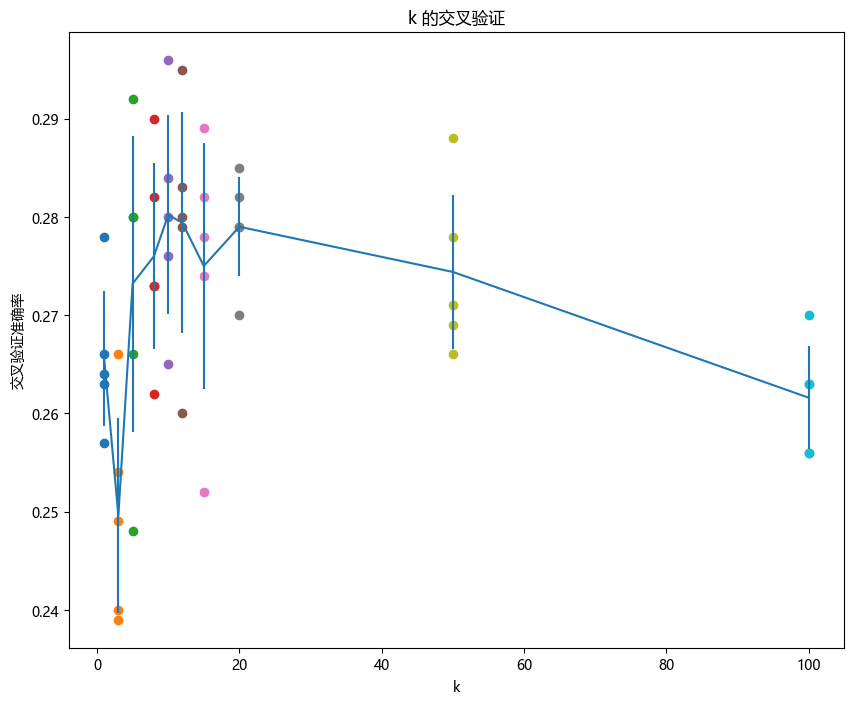

In [40]:
# 绘制原始观测结果
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# 绘制趋势线，并用误差条表示标准差
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('k 的交叉验证')
plt.xlabel('k')
plt.ylabel('交叉验证准确率')
plt.show()

In [59]:
# 根据上述交叉验证结果，选择最佳的 k 值，
# 使用全部训练数据重新训练分类器，并在测试数据上进行测试。
# 你应该能够在测试数据上获得超过 28% 的准确率。
best_k = 10

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# 计算并显示准确率
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('预测正确 %d / %d => 准确率: %f' % (num_correct, num_test, accuracy))

预测正确 141 / 500 => 准确率: 0.282000


**内联问题 3**

在分类设置中，以下关于 k 近邻（k-NN）的陈述哪些是正确的，且对所有 k 都成立？请选择所有适用的选项。
1. k-NN 分类器的决策边界是线性的。
2. 1-NN 的训练误差总是低于或等于 5-NN 的训练误差。
3. 1-NN 的测试误差总是低于 5-NN 的测试误差。
4. 使用 k-NN 分类器对测试样本进行分类所需的时间随着训练集的大小而增加。
5. 以上都不是。

$\color{blue}{\textit{你的答案：}}$

2、4

$\color{blue}{\textit{你的解释：}}$

1. k-NN 分类器的决策边界是非线性的。k-NN 根据训练样本的分布形成决策边界，通常是复杂且非线性的。
2. 1-NN 的训练误差总是低于或等于 5-NN 的训练误差。因为 1-NN 直接使用最近的训练样本进行分类，训练误差最小；而 5-NN 需要考虑多个邻居，可能会引入更多错误。
3. 1-NN 的测试误差不一定低于 5-NN 的测试误差。1-NN 可能过拟合训练数据，在测试集上表现较差；而 5-NN 通过考虑多个邻居，可能更鲁棒，测试误差可能更低。
4. 使用 k-NN 分类器对测试样本进行分类所需的时间随着训练集的大小而增加。因为 k-NN 需要计算测试样本与所有训练样本之间的距离，训练集越大，计算量越大。

# 图像特征练习  
*请完成并提交这份完整的练习表（包括所有输出结果以及表格外部的支撑代码），与本次作业一并上传。更多细节请参见课程官网的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

在前面的实验中，我们已经看到，直接在输入图像的原始像素上训练线性分类器，可以在图像分类任务上取得尚可的表现。  
在本练习中，我们将证明：如果不再使用原始像素，而是使用从原始像素**计算得到的特征**来训练线性分类器，可以进一步提升分类性能。

本练习的所有工作都将在本 notebook 内完成。

In [4]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# 让 Matplotlib 在 notebook 内直接显示图片
%matplotlib inline
# 统一设置图片默认尺寸，方便查看
plt.rcParams['figure.figsize'] = (10.0, 8.0)
# 关闭插值，使像素边界更清晰
plt.rcParams['image.interpolation'] = 'nearest'
# 灰度图默认使用灰度色图
plt.rcParams['image.cmap'] = 'gray'

# 开启 IPython 的自动重载功能：当外部 .py 文件被修改后，无需重启 kernel 即可立即生效
# 官方文档/讨论贴：http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# 注：由于网络原因，上述链接解析失败。如果你需要查看具体内容，请自行检查链接是否有效或稍后重试。
%load_ext autoreload
%autoreload 2

## 加载数据
与之前的练习一样，我们将从磁盘加载 CIFAR-10 数据集。

In [5]:
# 从 cs231n.features 导入两种常用图像特征提取函数：
# - color_histogram_hsv：将图像转成 HSV 空间后统计颜色直方图
# - hog_feature：计算 HOG（方向梯度直方图）特征
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    """
    加载并划分 CIFAR-10 数据集。

    参数
    ----
    num_training : int
        训练集样本数（默认 49000）
    num_validation : int
        验证集样本数（默认 1000）
    num_test : int
        测试集样本数（默认 1000）

    返回
    ----
    X_train, y_train, X_val, y_val, X_test, y_test : ndarray
        划分好的训练/验证/测试图像及对应标签
    """

    # CIFAR-10 二进制文件所在目录
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # 如果之前已经加载过数据，先手动清理变量，防止重复加载导致内存占用过高
    try:
        del X_train, y_train
        del X_test, y_test
        print('已清空之前加载的数据。')
    except:
        pass

    # 真正从磁盘读取 CIFAR-10 数据
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # 从训练集中划分出验证集
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]

    # 截取指定数量的训练样本
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]

    # 截取指定数量的测试样本
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

# 调用函数，获得划分好的数据
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## 提取特征
对于每张图像，我们将计算两种特征：
1. **HOG（方向梯度直方图，Histogram of Oriented Gradients）**
2. **HSV 颜色空间中 Hue 通道的颜色直方图**

随后，我们把这两种特征向量**拼接（concatenate）**在一起，作为该图像最终的特征向量。

简单而言：
- HOG 主要捕捉图像的**纹理信息**，同时忽略颜色；
- 颜色直方图则主要反映图像的**颜色分布**，同时忽略纹理。

因此，将二者结合使用，通常会比单独使用其中任何一种效果更好。你可以利用这一点做进一步的实验验证。

`hog_feature` 和 `color_histogram_hsv` 两个函数都针对**单张图像**计算并返回对应的特征向量。  
`extract_features` 函数接收一组图像和一组特征函数，依次在每个图像上调用这些特征函数，并把结果按列拼接成一个矩阵：矩阵的每一列就是单张图像经过所有特征函数后得到的完整特征向量。

In [6]:
# 从 cs231n.features 中导入所有自定义特征提取工具
from cs231n.features import *

# 设置颜色直方图的桶数（bin 个数）
num_color_bins = 25

# 定义要提取的特征函数列表：
# 1. hog_feature：计算 HOG（方向梯度直方图）特征
# 2. lambda img: color_histogram_hsv(img, nbin=num_color_bins)
#    用匿名函数包装 color_histogram_hsv，指定桶数为 num_color_bins
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]

# 依次对训练、验证、测试集提取上述两类特征
# extract_features 会把每张图像得到的所有特征向量拼接成一行
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats   = extract_features(X_val,   feature_fns)
X_test_feats  = extract_features(X_test,  feature_fns)

# ---------------- 特征预处理 ----------------
# 1. 去均值：用训练集特征的均值对所有集合作中心化
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats   -= mean_feat
X_test_feats  -= mean_feat

# 2. 标准化：除以训练集特征的标准差，使每个特征维度尺度大致相同
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats   /= std_feat
X_test_feats  /= std_feat

# 3. 添加偏置维度（bias term）：在特征矩阵最右侧拼接一列全 1
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats   = np.hstack([X_val_feats,   np.ones((X_val_feats.shape[0], 1))])
X_test_feats  = np.hstack([X_test_feats,  np.ones((X_test_feats.shape[0], 1))])

已完成 1000 / 49000 张图像的特征提取
已完成 2000 / 49000 张图像的特征提取
已完成 3000 / 49000 张图像的特征提取
已完成 4000 / 49000 张图像的特征提取
已完成 5000 / 49000 张图像的特征提取
已完成 6000 / 49000 张图像的特征提取
已完成 7000 / 49000 张图像的特征提取
已完成 8000 / 49000 张图像的特征提取
已完成 9000 / 49000 张图像的特征提取
已完成 10000 / 49000 张图像的特征提取
已完成 11000 / 49000 张图像的特征提取
已完成 12000 / 49000 张图像的特征提取
已完成 13000 / 49000 张图像的特征提取
已完成 14000 / 49000 张图像的特征提取
已完成 15000 / 49000 张图像的特征提取
已完成 16000 / 49000 张图像的特征提取
已完成 17000 / 49000 张图像的特征提取
已完成 18000 / 49000 张图像的特征提取
已完成 19000 / 49000 张图像的特征提取
已完成 20000 / 49000 张图像的特征提取
已完成 21000 / 49000 张图像的特征提取
已完成 22000 / 49000 张图像的特征提取
已完成 23000 / 49000 张图像的特征提取
已完成 24000 / 49000 张图像的特征提取
已完成 25000 / 49000 张图像的特征提取
已完成 26000 / 49000 张图像的特征提取
已完成 27000 / 49000 张图像的特征提取
已完成 28000 / 49000 张图像的特征提取
已完成 29000 / 49000 张图像的特征提取
已完成 30000 / 49000 张图像的特征提取
已完成 31000 / 49000 张图像的特征提取
已完成 32000 / 49000 张图像的特征提取
已完成 33000 / 49000 张图像的特征提取
已完成 34000 / 49000 张图像的特征提取
已完成 35000 / 49000 张图像的特征提取
已完成 36000 / 49000 张图像的特征提取
已完成 37000 / 49000 张图像的特征提取
已完成 38000 

## 在特征之上训练 Softmax 分类器
利用作业前面部分已经实现的 Softmax 代码，在刚才提取好的特征之上训练 Softmax 分类器；  
与直接在原始像素上训练相比，这种做法应当能够获得更高的准确率。

In [37]:
# 利用验证集对学习率和正则化强度进行网格搜索调参
from cs231n.classifiers.linear_classifier import Softmax

# 设定待搜索的学习率和正则化强度候选值
learning_rates = [1.5e-7, 2e-7, 2.5e-7, 3e-7, 3.5e-7, 4e-7, 4.5e-7, 5e-7, 5.5e-7, 6e-7]
regularization_strengths = [2e3, 2500, 3e3, 3500, 4e3, 4500, 5e3, 5500, 6e3, 7e3]

# 用于保存不同超参数组合下的训练/验证结果
results = {}
best_val = -1              # 目前最高的验证准确率
best_softmax = None        # 对应最高验证准确率的 Softmax 分类器

################################################################################
# 代办: 请在此区域内完成以下任务                                                 #
# 使用验证集对学习率和正则化强度进行调参。                                       #
# 这与你在 Softmax 作业中做过的验证流程完全一致；                                #
# 请将训练出的最佳分类器保存到 best_softmax。                                   #
# 如果仔细调参，你应该能够在验证集上得到超过 0.42 的准确率。                     #
################################################################################
# 使用已提取的特征（X_train_feats 等）进行训练，不需要 reshape
# 注意：X_train_feats 已经包含偏置列，直接使用

for lr in learning_rates:
    for reg in regularization_strengths:
        # 创建Softmax模型
        softmax = Softmax()
        
        # 训练模型
        softmax.train(X_train_feats, y_train, learning_rate=lr, reg=reg, num_iters=3000, verbose=False)
        
        # 计算训练集和验证集准确率
        y_train_pred = softmax.predict(X_train_feats)
        y_val_pred = softmax.predict(X_val_feats)
        y_test_pred = softmax.predict(X_test_feats)
        
        train_acc = np.mean(y_train == y_train_pred)
        val_acc = np.mean(y_val == y_val_pred)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax


# 打印调参结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e  reg %e  训练准确率: %f  验证准确率: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('在验证集上取得的最高准确率: %f' % best_val)

lr 1.500000e-07  reg 2.000000e+03  训练准确率: 0.107531  验证准确率: 0.102000
lr 1.500000e-07  reg 2.500000e+03  训练准确率: 0.136041  验证准确率: 0.128000
lr 1.500000e-07  reg 3.000000e+03  训练准确率: 0.149551  验证准确率: 0.138000
lr 1.500000e-07  reg 3.500000e+03  训练准确率: 0.165857  验证准确率: 0.175000
lr 1.500000e-07  reg 4.000000e+03  训练准确率: 0.143449  验证准确率: 0.164000
lr 1.500000e-07  reg 4.500000e+03  训练准确率: 0.184408  验证准确率: 0.210000
lr 1.500000e-07  reg 5.000000e+03  训练准确率: 0.198531  验证准确率: 0.203000
lr 1.500000e-07  reg 5.500000e+03  训练准确率: 0.221367  验证准确率: 0.227000
lr 1.500000e-07  reg 6.000000e+03  训练准确率: 0.264327  验证准确率: 0.289000
lr 1.500000e-07  reg 7.000000e+03  训练准确率: 0.357571  验证准确率: 0.372000
lr 2.000000e-07  reg 2.000000e+03  训练准确率: 0.123122  验证准确率: 0.148000
lr 2.000000e-07  reg 2.500000e+03  训练准确率: 0.163327  验证准确率: 0.167000
lr 2.000000e-07  reg 3.000000e+03  训练准确率: 0.177469  验证准确率: 0.172000
lr 2.000000e-07  reg 3.500000e+03  训练准确率: 0.210163  验证准确率: 0.221000
lr 2.000000e-07  reg 4.000000e+03  训练准确率: 0.2655

In [38]:
# 在测试集上评估最终训练好的 Softmax 分类器
# 要求测试准确率至少达到 0.42
y_test_pred = best_softmax.predict(X_test_feats)      # 用最佳模型预测测试集标签
test_accuracy = np.mean(y_test == y_test_pred)        # 计算测试集准确率
print(test_accuracy)                                  # 打印结果

0.42


In [40]:
# 将训练得到的最优 Softmax 模型保存到文件
# 后续可直接加载 best_softmax_features.npy 复用该模型，无需重新训练
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy 已保存。


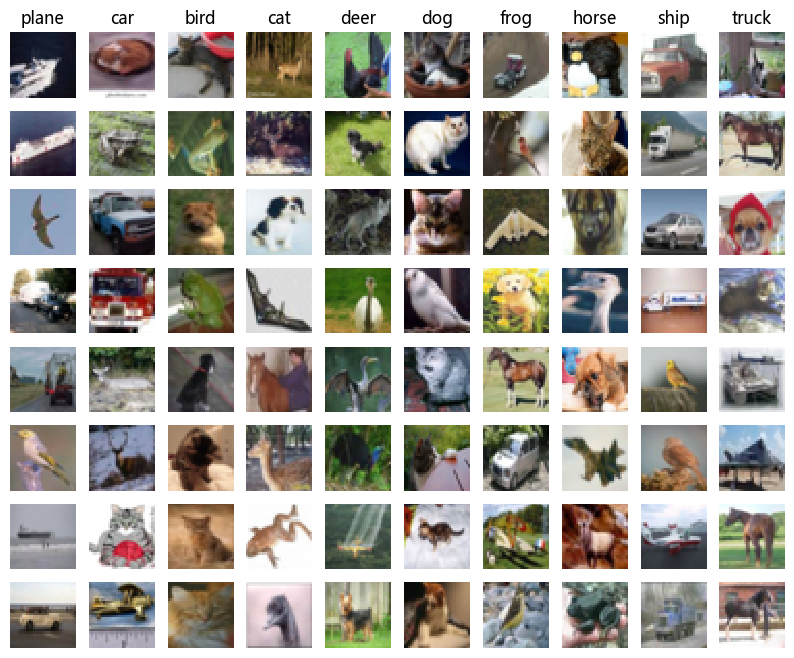

In [41]:
# 通过可视化算法的错误样本来加深对其工作方式的理解是一种重要手段。
# 下面展示当前系统误分类的示例。
# 第一列展示的是被模型标记为“飞机”(plane)，但真实标签却并非“飞机”的图片。

examples_per_class = 8           # 每个类别展示 8 张误分类图
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']  # CIFAR-10 的 10 个类别名

# 遍历每个类别
for cls, cls_name in enumerate(classes):
    # 找出满足“真实标签 ≠ cls 且预测标签 = cls”的测试样本下标
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    # 随机挑 examples_per_class 张图，不重复
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    
    # 依次绘制图片
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes),
                    i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))  # 显示原始图像
        plt.axis('off')                          # 去掉坐标轴
        # 只在第一行写类别名作为标题
        if i == 0:
            plt.title(cls_name)

plt.show()

### 内联问题 1：
请描述你观察到的误分类结果。它们是否合理？

$\color{blue}{\textit{你的答案：}}$


这些误分类是完全合理的，原因如下：

数据本身的局限性：CIFAR-10 图片分辨率仅为 32×32，细节丢失严重，很多类别的关键特征（如猫的尖耳朵、狗的口鼻轮廓）难以被捕捉。

类别间的天然相似性：很多类别在视觉特征上存在重叠，比如：

猫和狗：都是小型四足动物，毛发纹理和姿态高度相似。

青蛙和鸟：绿色皮肤 / 羽毛 + 简单轮廓，低分辨率下难以区分。

模型能力的限制：线性 Softmax 或浅层全连接网络，仅能学习简单的线性特征，无法捕捉复杂的纹理、局部特征和上下文信息，因此容易被颜色、背景等浅层特征误导。



## 在图像特征上训练神经网络
在作业的前面部分，我们已经看到：  
在原始像素上训练两层神经网络，其分类效果优于直接在原始像素上训练的线性分类器。  
而在本 notebook 中，我们又发现：在图像特征上训练的线性分类器，效果比在原始像素上训练的线性分类器更好。

为了完整性，我们还应该在图像特征上训练神经网络。  
这种做法应当能超越之前所有方案：你很容易就能在测试集上获得 **超过 55%** 的分类准确率；  
我们最好的模型能达到约 **60%** 的测试准确率。

In [42]:
# 预处理：去掉之前添加的偏置维度（bias dimension）
# 注意：此代码单元只需执行一次！

print("原始特征维度：", X_train_feats.shape)  # 查看当前形状（最后一列为偏置 1）

# 通过切片去掉最后一列（bias 列）
X_train_feats = X_train_feats[:, :-1]
X_val_feats   = X_val_feats[:, :-1]
X_test_feats  = X_test_feats[:, :-1]

print("去掉偏置后的特征维度：", X_train_feats.shape)

原始特征维度： (49000, 170)
去掉偏置后的特征维度： (49000, 169)


In [75]:
# 从 cs231n 中导入两层全连接网络 TwoLayerNet 以及通用训练器 Solver
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

# 设置网络参数
input_dim   = X_train_feats.shape[1]   # 输入特征维度
hidden_dim  = 500                      # 隐藏层神经元个数
num_classes = 10                       # 输出类别数（CIFAR-10 共 10 类）

# 将训练、验证、测试数据打包成字典，方便 Solver 使用
data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val':   X_val_feats,
    'y_val':   y_val,
    'X_test':  X_test_feats,
    'y_test':  y_test,
}

# 初始化两层神经网络
net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None   # 用于保存训练出的最优模型

################################################################################
# 代办: 在提取的图像特征上训练两层神经网络。你可以像前面章节一样进行交叉验证调参。  #
# 将最终表现最好的模型保存到 best_net 变量中。                                   #
################################################################################

# 设定待搜索的学习率和正则化强度候选值
learning_rates = [1.5e-1, 1.8e-1, 2e-1, 2.2e-1]
regularization_strengths = [1.5e-3, 1.8e-3, 2e-3, 2.2e-3, 2.5e-3, 2.8e-3, 3e-3]

# 用于保存不同超参数组合下的训练/验证结果
results = {}
best_val = -1              # 目前最高的验证准确率
best_net = None            # 对应最高验证准确率的神经网络

# 网格搜索所有超参数组合
for lr in learning_rates:
    for reg in regularization_strengths:
        # 创建两层神经网络
        net = TwoLayerNet(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes)
        
        # 使用Solver训练网络
        solver = Solver(net, data,
                        update_rule='sgd',
                        optim_config={
                            'learning_rate': lr,
                        },
                        lr_decay=0.95,
                        num_epochs=20, 
                        batch_size=256,
                        verbose=False, print_every=500)
        
        # 训练模型
        solver.train()
        
        # 计算训练集和验证集准确率
        y_train_pred = np.argmax(net.loss(data['X_train']), axis=1)
        y_val_pred = np.argmax(net.loss(data['X_val']), axis=1)
        
        train_acc = np.mean(y_train == y_train_pred)
        val_acc = np.mean(y_val == y_val_pred)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_net = net

# 打印调参结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e  reg %e  训练准确率: %f  验证准确率: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('在验证集上取得的最高准确率: %f' % best_val)


lr 1.500000e-01  reg 1.500000e-03  训练准确率: 0.680796  验证准确率: 0.603000
lr 1.500000e-01  reg 1.800000e-03  训练准确率: 0.685184  验证准确率: 0.625000
lr 1.500000e-01  reg 2.000000e-03  训练准确率: 0.675286  验证准确率: 0.606000
lr 1.500000e-01  reg 2.200000e-03  训练准确率: 0.670286  验证准确率: 0.614000
lr 1.500000e-01  reg 2.500000e-03  训练准确率: 0.680735  验证准确率: 0.605000
lr 1.500000e-01  reg 2.800000e-03  训练准确率: 0.674653  验证准确率: 0.608000
lr 1.500000e-01  reg 3.000000e-03  训练准确率: 0.683082  验证准确率: 0.607000
lr 1.800000e-01  reg 1.500000e-03  训练准确率: 0.714408  验证准确率: 0.605000
lr 1.800000e-01  reg 1.800000e-03  训练准确率: 0.713878  验证准确率: 0.611000
lr 1.800000e-01  reg 2.000000e-03  训练准确率: 0.684061  验证准确率: 0.605000
lr 1.800000e-01  reg 2.200000e-03  训练准确率: 0.702327  验证准确率: 0.605000
lr 1.800000e-01  reg 2.500000e-03  训练准确率: 0.700082  验证准确率: 0.612000
lr 1.800000e-01  reg 2.800000e-03  训练准确率: 0.717306  验证准确率: 0.614000
lr 1.800000e-01  reg 3.000000e-03  训练准确率: 0.688796  验证准确率: 0.618000
lr 2.000000e-01  reg 1.500000e-03  训练准确率: 0.7201

In [90]:
# 在测试集上运行你表现最好的神经网络分类器
# 你应该能够获得超过 58% 的准确率；如果仔细调参，甚至可以超过 60%。

# 使用 best_net 计算测试样本属于各类别的得分
y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)  # 取得分最高的类别作为预测结果
test_acc = (y_test_pred == data['y_test']).mean()               # 计算测试集准确率
print(test_acc)                                                 # 打印结果

0.594


In [81]:
# 将表现最佳的两层神经网络模型保存到文件
# 后续可直接加载 best_two_layer_net_features.npy，无需重新训练
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy 已保存。


# Softmax 分类器练习

*请将这份完整的练习表（包括所有输出结果以及表格外部的支持代码）随本次作业一并提交。更多详情见课程官网的[作业页面](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

在本练习中，你将：

- 实现 Softmax 分类器的**完全向量化损失函数**。
- 实现其**解析梯度**的完全向量化表达式。
- 使用数值梯度**验证你的实现**。
- 使用验证集**调整学习率和正则化强度**。
- 使用**随机梯度下降SGD**优化损失函数。
- **可视化**最终学习到的权重。


In [1]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 运行本 notebook 所需的初始化代码

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10   # 加载 CIFAR-10 数据的工具函数
import matplotlib.pyplot as plt

# 让 matplotlib 图形直接嵌入在 notebook 中，而不是弹出新窗口
%matplotlib inline
# 统一设置图片默认大小，便于查看
plt.rcParams['figure.figsize'] = (10.0, 8.0)
# 关闭插值，使像素边界更清晰
plt.rcParams['image.interpolation'] = 'nearest'
# 灰度图默认使用灰度色图
plt.rcParams['image.cmap'] = 'gray'

# 开启 IPython 的自动重载功能：修改外部 .py 文件后无需重启 kernel 即可生效
# 官方讨论贴地址：http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# 注意：由于网络原因，上述链接暂时无法成功解析。如果你需要查看该网页内容，
# 请检查链接是否有效，或稍后重试；若不需要查看，可直接继续后续操作。
%load_ext autoreload
%autoreload 2

## CIFAR-10 数据加载与预处理

In [2]:
# 加载原始 CIFAR-10 数据
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# 如果之前已加载过数据，先删除相关变量，防止重复加载导致内存占用过高
try:
    del X_train, y_train
    del X_test, y_test
    print('已清空之前加载的数据。')
except:
    pass

# 真正从磁盘读取 CIFAR-10
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 简单检查：打印训练集和测试集的形状
print('训练数据形状: ', X_train.shape)
print('训练标签形状: ', y_train.shape)
print('测试数据形状: ', X_test.shape)
print('测试标签形状: ', y_test.shape)

训练数据形状:  (50000, 32, 32, 3)
训练标签形状:  (50000,)
测试数据形状:  (10000, 32, 32, 3)
测试标签形状:  (10000,)


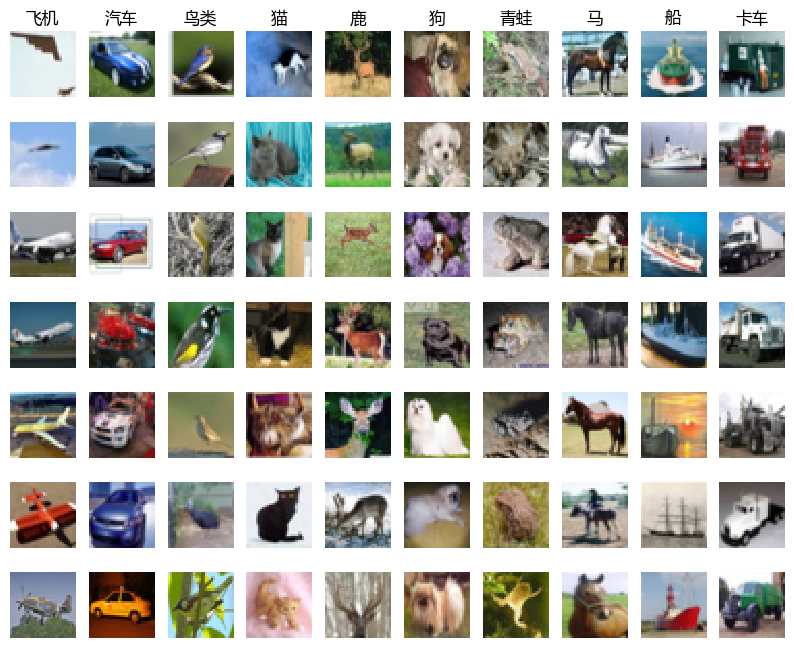

In [3]:
# 可视化数据集中的一些样本
# 从每个类别中随机展示若干张训练图像

classes = ['飞机', '汽车', '鸟类', '猫', '鹿', '狗', '青蛙', '马', '船', '卡车']
num_classes = len(classes)              # 类别数（10）
samples_per_class = 7                   # 每类展示 7 张图

for y, cls in enumerate(classes):
    # 找到所有属于当前类别的训练样本索引
    idxs = np.flatnonzero(y_train == y)
    # 随机选择 7 张且不重复
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    
    for i, idx in enumerate(idxs):
        # 计算子图位置
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        # 显示图像
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        # 只在第一行写类别名
        if i == 0:
            plt.title(cls)

plt.show()

In [4]:
# 将数据划分为训练集、验证集和测试集。此外，我们还将从训练集中创建一个小型开发集，
# 作为训练集的一个子集；我们可以在开发过程中使用这个开发集，这样代码运行会更快。
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# 验证集是从原始训练集中选取的 num_validation 个样本
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# 训练集是从原始训练集中选取的前 num_training 个样本
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# 开发集是从训练集中随机选取的 num_dev 个样本
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# 测试集是从原始测试集中选取的前 num_test 个样本
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

# 打印各数据集的形状
print('训练数据形状: ', X_train.shape)
print('训练标签形状: ', y_train.shape)
print('验证数据形状: ', X_val.shape)
print('验证标签形状: ', y_val.shape)
print('测试数据形状: ', X_test.shape)
print('测试标签形状: ', y_test.shape)

训练数据形状:  (49000, 32, 32, 3)
训练标签形状:  (49000,)
验证数据形状:  (1000, 32, 32, 3)
验证标签形状:  (1000,)
测试数据形状:  (1000, 32, 32, 3)
测试标签形状:  (1000,)


In [5]:
# 预处理：将图像数据展平成行向量
X_train = np.reshape(X_train, (X_train.shape[0], -1))  # 展平训练集
X_val   = np.reshape(X_val,   (X_val.shape[0],   -1))  # 展平验证集
X_test  = np.reshape(X_test,  (X_test.shape[0],  -1))  # 展平测试集
X_dev   = np.reshape(X_dev,   (X_dev.shape[0],   -1))  # 展平开发集

# 简单检查：打印各数据集的形状
print('训练数据形状: ', X_train.shape)
print('验证数据形状: ', X_val.shape)
print('测试数据形状: ', X_test.shape)
print('开发数据形状: ', X_dev.shape)

训练数据形状:  (49000, 3072)
验证数据形状:  (1000, 3072)
测试数据形状:  (1000, 3072)
开发数据形状:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


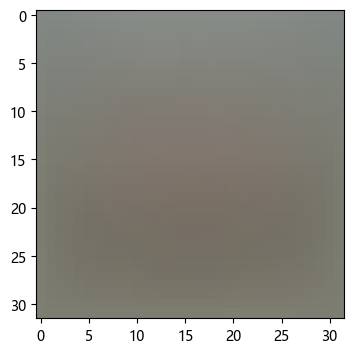

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [6]:
# 预处理：减去均值图像
# 首先：根据训练数据计算均值图像
mean_image = np.mean(X_train, axis=0)  # 按列计算均值
print(mean_image[:10])  # 打印前 10 个元素
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((32, 32, 3)).astype('uint8'))  # 可视化均值图像
plt.show()

# 其次：从训练数据和测试数据中减去均值图像
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# 最后：添加偏置维度（全为 1 的列），即偏置技巧，这样分类器只需优化一个权重矩阵 W。
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

# 打印各数据集的形状
print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax 分类器

本节的所有代码都将写在 `cs231n/classifiers/softmax.py` 文件中。

正如你所看到的，我们已经预先填充了函数 `softmax_loss_naive`，它使用 for 循环来计算 Softmax 损失函数。

In [8]:
# 测试我们提供的朴素 Softmax 损失函数实现
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# 生成一个随机的 Softmax 分类器权重矩阵，数值很小
W = np.random.randn(3073, 10) * 0.0001

# 计算损失和梯度
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('损失: %f' % loss)

# 简单检查：损失值应接近 -log(0.1)
print('损失: %f' % loss)
print('合理性检查: %f' % (-np.log(0.1)))

损失: 2.372500
损失: 2.372500
合理性检查: 2.302585


**内联问题 1**

为什么我们期望损失接近 -log(0.1)？请简要解释。

$\color{blue}{\textit{你的答案：}}$

当权重矩阵 $W$ 的数值非常小（接近零）时，对于任意输入样本 $x$，其属于各个类别的得分 $x^T W$ 都接近于 0。

在 Softmax 函数中：

$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}$$

当所有得分 $z_i \approx 0$ 时，$e^{z_i} \approx 1$，因此每个类别的概率近似相等：

$$p_i \approx \frac{1}{C} = \frac{1}{10} = 0.1$$

Softmax 的损失函数（交叉熵损失）为：

$$L = -\log(p_{y})$$

其中 $y$ 是真实类别。由于每个类别的概率都约为 0.1，所以：

$$L \approx -\log(0.1) $$

目前，上述函数返回的 `grad` 全部为零。  
请推导并实现 softmax 损失函数的梯度，并在 `softmax_loss_naive` 函数内部直接完成实现。  
建议将新代码穿插在现有函数中，而非重写整个函数。

为了验证你的梯度实现是否正确，可以利用数值方法估计损失函数的梯度，并将其与你计算出的解析梯度进行比较。  
我们已为你提供了相应的检查代码：

In [20]:
# 一旦你实现了梯度，请用下面的代码重新计算
# 并用我们提供的函数进行梯度检查

# 计算当前权重 W 下的损失及梯度（无正则化）
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# 在若干随机维度上数值计算梯度，并与解析梯度对比；
# 两者应在所有维度上几乎完全一致。
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# 再次进行梯度检查，这次开启正则化；
# 别忘了正则项的梯度也要一起实现！
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

数值梯度: 0.657830, 解析梯度: 0.657830, 相对误差: 5.111148e-08
数值梯度: 1.241190, 解析梯度: 1.241190, 相对误差: 1.648712e-09
数值梯度: -0.208800, 解析梯度: -0.208800, 相对误差: 3.166233e-07
数值梯度: -0.024533, 解析梯度: -0.024533, 相对误差: 3.341029e-07
数值梯度: -1.702249, 解析梯度: -1.702249, 相对误差: 1.448231e-08
数值梯度: -1.663407, 解析梯度: -1.663407, 相对误差: 4.984885e-09
数值梯度: -0.025992, 解析梯度: -0.025992, 相对误差: 2.026742e-06
数值梯度: -0.149027, 解析梯度: -0.149027, 相对误差: 7.776485e-08
数值梯度: 0.397103, 解析梯度: 0.397103, 相对误差: 1.157227e-07
数值梯度: -0.070180, 解析梯度: -0.070180, 相对误差: 3.854395e-07
数值梯度: 0.956299, 解析梯度: 0.956299, 相对误差: 4.330272e-08
数值梯度: 2.199845, 解析梯度: 2.199845, 相对误差: 3.496276e-08
数值梯度: -0.742006, 解析梯度: -0.742006, 相对误差: 1.958858e-08
数值梯度: 1.674853, 解析梯度: 1.674853, 相对误差: 2.611115e-08
数值梯度: 0.064260, 解析梯度: 0.064260, 相对误差: 9.559251e-07
数值梯度: 0.645187, 解析梯度: 0.645187, 相对误差: 8.545552e-08
数值梯度: 2.715514, 解析梯度: 2.715514, 相对误差: 4.227955e-09
数值梯度: -0.192038, 解析梯度: -0.192038, 相对误差: 2.643296e-08
数值梯度: -0.274522, 解析梯度: -0.274522, 相对误差: 1.276461e-07
数值梯度: 0.232

**内联问题 2**

尽管 gradcheck 对于 Softmax 损失通常是可靠的，但在 SVM 损失上偶尔会出现某个维度与数值梯度不完全匹配的情况。  
这种差异可能由什么原因引起？是否需要担心？  
请举一个最简单的一维例子说明 SVM 损失梯度检查可能失败的情形。  
改变 margin Δ 会如何影响这种现象的出现频率？

提示：SVM 损失函数在严格意义上并不可微。

$\color{blue}{\textit{你的答案：}}$



SVM 损失函数在严格意义上并不可微。SVM 的损失函数定义为：

$$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + \Delta)$$

这个函数在 $s_j - s_{y_i} + \Delta = 0$ 处存在尖点，在这些点上梯度是不连续的。数值梯度使用有限差分近似：

$$\frac{\partial L}{\partial w_k} \approx \frac{L(w_k + \epsilon) - L(w_k - \epsilon)}{2\epsilon}$$

当采样点恰好落在尖点附近时，数值梯度和解析梯度可能不一致。


不需要担心。只是数值精度问题，不影响训练的正确性。SVM 在尖点处可以使用次梯度，通常取 0 或某个边界值。

**例子：**

考虑一维 SVM 损失函数 $L(w) = \max(0, |w| - 1)$。

- 当 $w = 1$ 时，$L(1) = 0$
- 当 $w = 1 + \epsilon$ 时，$L(1+\epsilon) = \epsilon$，解析梯度为 1
- 当 $w = 1 - \epsilon$ 时，$L(1-\epsilon) = 0$，解析梯度为 0

数值梯度：
$$\frac{L(1+\epsilon) - L(1-\epsilon)}{2\epsilon} = \frac{\epsilon - 0}{2\epsilon} = 0.5$$

而解析梯度在 $w=1$ 处要么是 0，要么是 1（取决于取哪一侧的次梯度），与数值梯度 0.5 不匹配。

**改变 margin $\Delta$ 的影响：**

- 增大 $\Delta$：会使更多样本满足 $s_j - s_{y_i} + \Delta > 0$，即更多样本处于"平滑区域"，梯度检查不匹配的频率降低。
- 减小 $\Delta$：会使更多样本落在 $s_j - s_{y_i} + \Delta \approx 0$ 的尖点附近，梯度检查不匹配的频率增加。



In [24]:
# 接下来实现 softmax_loss_vectorized 函数；目前只需计算损失值，
# 稍后再实现梯度。
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('朴素实现损失: %e，耗时 %f 秒' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('向量化实现损失: %e，耗时 %f 秒' % (loss_vectorized, toc - tic))

# 两种实现计算出的损失值应一致，但向量化版本应快得多。
print('损失差值: %f' % (loss_naive - loss_vectorized))

朴素实现损失: 2.372500e+00，耗时 0.082342 秒
向量化实现损失: 2.372500e+00，耗时 0.019541 秒
损失差值: 0.000000


In [25]:
# 补全 softmax_loss_vectorized 的实现，并以向量化方式计算损失函数的梯度。

# 朴素实现与向量化实现应得到相同结果，但向量化版本速度应更快。
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('朴素实现损失与梯度：耗时 %f 秒' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('向量化实现损失与梯度：耗时 %f 秒' % (toc - tic))

# 损失是一个标量，直接比较即可；梯度是矩阵，用 Frobenius 范数比较。
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('梯度差异: %f' % difference)

朴素实现损失与梯度：耗时 0.098751 秒
向量化实现损失与梯度：耗时 0.006770 秒
梯度差异: 0.000000


### 随机梯度下降（SGD）

我们现在已经得到了向量化且高效计算损失、梯度的实现，并且梯度与数值梯度一致，因此可以使用随机梯度下降（SGD）来最小化损失。  
本部分的代码将写在 `cs231n/classifiers/linear_classifier.py` 中。

In [27]:
# 在文件 linear_classifier.py 中，请在函数 LinearClassifier.train() 里实现 SGD，
# 然后用以下代码运行它。

from cs231n.classifiers import Softmax
softmax = Softmax()                 # 创建 Softmax 分类器实例

tic = time.time()
# 开始训练，使用给定的学习率、正则化系数，迭代 1500 次，并打印日志
loss_hist = softmax.train(
    X_train, y_train,
    learning_rate=1e-7,
    reg=2.5e4,
    num_iters=1500,
    verbose=True
)
toc = time.time()
print('训练耗时 %f 秒' % (toc - tic))

iteration 0 / 1500: loss 779.471798
iteration 100 / 1500: loss 285.754738
iteration 200 / 1500: loss 106.007405
iteration 300 / 1500: loss 40.068879
iteration 400 / 1500: loss 15.981673
iteration 500 / 1500: loss 7.161807
iteration 600 / 1500: loss 3.937467
iteration 700 / 1500: loss 2.744502
iteration 800 / 1500: loss 2.363760
iteration 900 / 1500: loss 2.141485
iteration 1000 / 1500: loss 2.134264
iteration 1100 / 1500: loss 2.100505
iteration 1200 / 1500: loss 2.093398
iteration 1300 / 1500: loss 2.113664
iteration 1400 / 1500: loss 2.066177
训练耗时 11.961595 秒


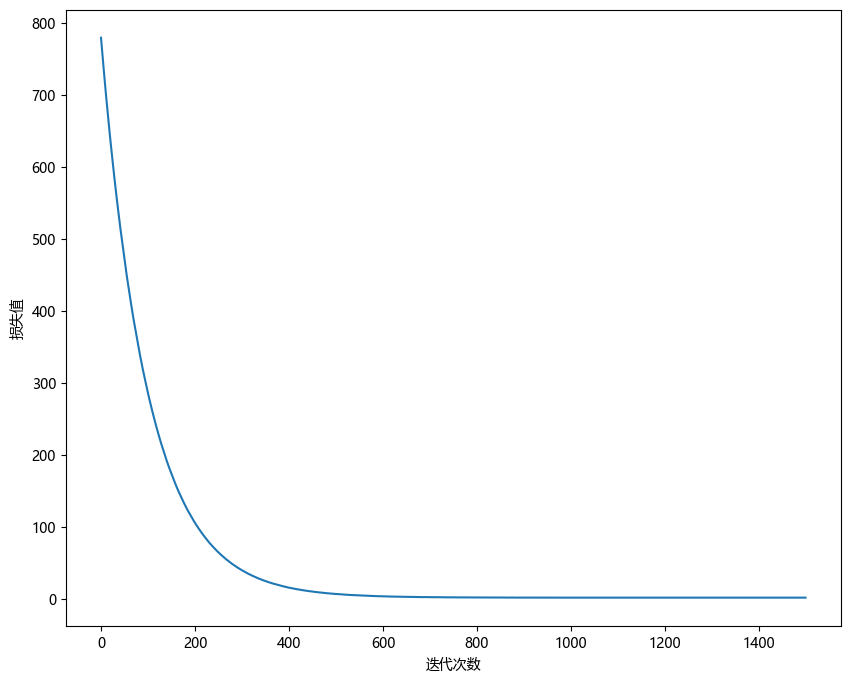

In [28]:
# 一种实用的调试策略是把损失值随迭代次数画出来
plt.plot(loss_hist)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.show()

In [29]:
# 实现 LinearClassifier.predict 函数，并评估在训练集和验证集上的表现
# 你应在验证集上获得约 0.34 (> 0.33) 的准确率

# 在训练集上预测
y_train_pred = softmax.predict(X_train)
print('训练准确率: %f' % (np.mean(y_train == y_train_pred), ))

# 在验证集上预测
y_val_pred = softmax.predict(X_val)
print('验证准确率: %f' % (np.mean(y_val == y_val_pred), ))

训练准确率: 0.325265
验证准确率: 0.339000


In [30]:
# 将训练好的模型保存，以便自动评分器使用
softmax.save("softmax.npy")

softmax.npy 已保存。


In [31]:
# 使用验证集来调优超参数（正则化强度和学习率）。
# 建议尝试不同的学习率和正则化强度范围；认真调参后，
# 你应在验证集上得到约 0.365（> 0.36）的准确率。
#
# 注意：在超参数搜索过程中可能会出现运行时/溢出警告，
# 这通常是由极端值引起的，并不是 bug。

# results 是一个字典，以 (learning_rate, regularization_strength) 为键，
# 对应的值为 (training_accuracy, validation_accuracy)。
# 准确率定义为被正确分类的数据点所占的比例。
results = {}
best_val = -1        # 目前观察到的最高验证准确率
best_softmax = None  # 达到最高验证准确率的 Softmax 对象

################################################################################
# 代办:                                                                         #
# 编写代码，在验证集上调优超参数。对于每一组超参数组合，                           #
# 在训练集上训练一个 Softmax 分类器，计算其在训练集和验证集上的准确率，            #
# 并将结果存入 results 字典。此外，将最高验证准确率存入 best_val，                #
# 并将达到该准确率的 Softmax 对象存入 best_softmax。                             #
#                                                                              #
# 提示：开发验证代码时可使用较小的 num_iters，这样训练更快；                      #
# 确认代码正确后，再用更大的 num_iters 重新运行。                                #
################################################################################

num_iters = 1000  # 训练迭代次数
batch_size = 256   # 批量大小

for lr in learning_rates:
    for reg in regularization_strengths:
        print(f'正在训练: lr={lr}, reg={reg}')
        
        # 初始化一个新的 Softmax 分类器
        softmax = Softmax()
        
        # 在训练集上训练
        softmax.train(
            X_train, y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=num_iters,
            batch_size=batch_size,
            verbose=False
        )
        
        # 计算训练集准确率
        y_train_pred = softmax.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        # 计算验证集准确率
        y_val_pred = softmax.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        # 保存结果
        results[(lr, reg)] = (train_accuracy, val_accuracy)
        
        # 更新最佳模型
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax
        
        print(f'  训练准确率: {train_accuracy:.4f}, 验证准确率: {val_accuracy:.4f}')

# 打印最终结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e 训练准确率: %f 验证准确率: %f' %
          (lr, reg, train_accuracy, val_accuracy))

print('交叉验证期间达到的最佳验证准确率: %f' % best_val)

正在训练: lr=1e-07, reg=25000.0
  训练准确率: 0.3295, 验证准确率: 0.3420
正在训练: lr=1e-07, reg=10000.0
  训练准确率: 0.3301, 验证准确率: 0.3320
正在训练: lr=1e-06, reg=25000.0
  训练准确率: 0.3198, 验证准确率: 0.3350
正在训练: lr=1e-06, reg=10000.0
  训练准确率: 0.3429, 验证准确率: 0.3650
lr 1.000000e-07 reg 1.000000e+04 训练准确率: 0.330102 验证准确率: 0.332000
lr 1.000000e-07 reg 2.500000e+04 训练准确率: 0.329490 验证准确率: 0.342000
lr 1.000000e-06 reg 1.000000e+04 训练准确率: 0.342857 验证准确率: 0.365000
lr 1.000000e-06 reg 2.500000e+04 训练准确率: 0.319755 验证准确率: 0.335000
交叉验证期间达到的最佳验证准确率: 0.365000


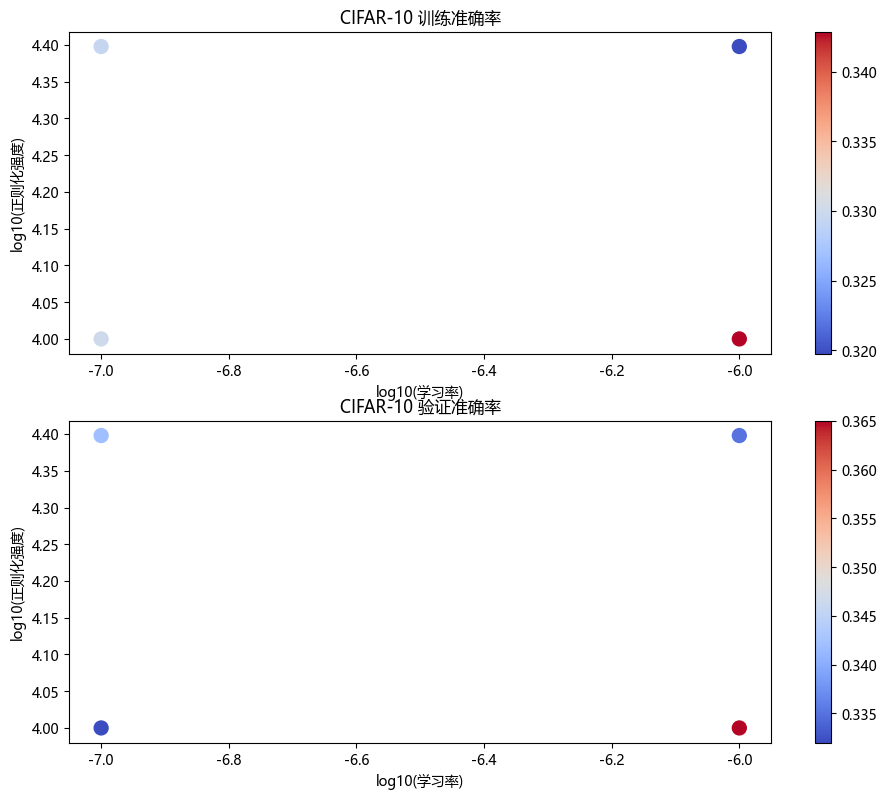

In [32]:
# 可视化交叉验证结果
import math
import pdb

# pdb.set_trace()

# 将学习率和正则化强度取对数，方便作图
x_scatter = [math.log10(x[0]) for x in results]   # log10(learning_rate)
y_scatter = [math.log10(x[1]) for x in results]   # log10(regularization_strength)

marker_size = 100

# 绘制训练准确率热力图
colors = [results[x][0] for x in results]                # 训练准确率
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log10(学习率)')
plt.ylabel('log10(正则化强度)')
plt.title('CIFAR-10 训练准确率')

# 绘制验证准确率热力图
colors = [results[x][1] for x in results]                # 验证准确率
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log10(学习率)')
plt.ylabel('log10(正则化强度)')
plt.title('CIFAR-10 验证准确率')
plt.show()

In [33]:
# 在测试集上评估最优 Softmax 模型
y_test_pred = best_softmax.predict(X_test)               # 预测测试集标签
test_accuracy = np.mean(y_test == y_test_pred)           # 计算测试准确率
print('基于原始像素的 Softmax 分类器最终测试集准确率: %f' % test_accuracy)

基于原始像素的 Softmax 分类器最终测试集准确率: 0.356000


In [34]:
# 保存最优的 Softmax 模型
best_softmax.save("best_softmax.npy")

best_softmax.npy 已保存。


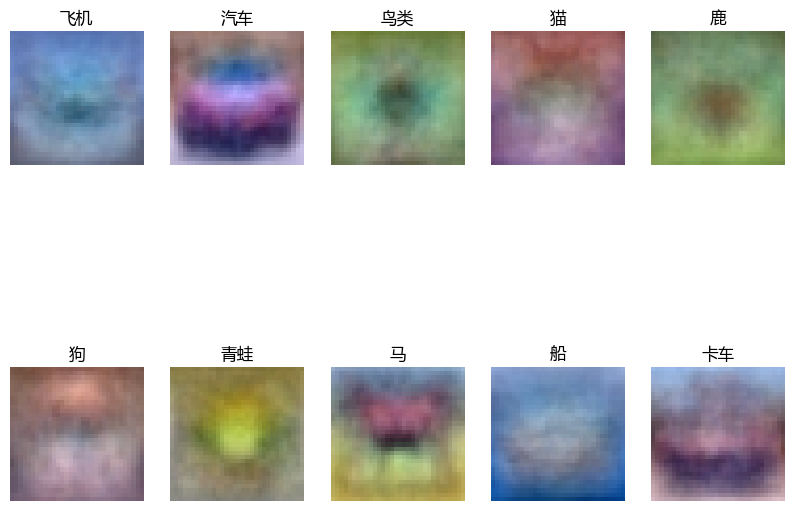

In [35]:
# 可视化每个类别学习到的权重（模板）
# 权重的美观程度取决于你选择的学习率和正则化强度
w = best_softmax.W[:-1, :]           # 去掉偏置项
w = w.reshape(32, 32, 3, 10)         # 重新调整形状为 (32,32,3,10)

w_min, w_max = np.min(w), np.max(w)  # 找到最小、最大值用于归一化
classes = ['飞机', '汽车', '鸟类', '猫', '鹿',
           '狗', '青蛙', '马', '船', '卡车']

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # 将权重线性缩放到 0–255 之间，便于显示
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

plt.show()

**内联问题 3**

请描述你可视化的 Softmax 分类器权重看起来像什么，并简要解释为什么它们看起来是这样的。

$\color{blue}{\textit{你的答案：}}$

**观察：**

- **飞机**：出天空背景（蓝色调）
- **汽车**：显示出车辆的车身轮廓
- **青蛙**：可能显示出绿色调和小动物轮廓
- **其他类别**：各自显示出对应物体的典型颜色和轮廓

**原因解释：**
1. 每个类别的权重向量 $W_k$ 可以看作该类别的"模板"或"特征检测器"。当输入图像与 $W_k$ 做内积时，实际上是在计算图像与该模板的相似度。

2. SGD 优化过程不断调整 $W$，使得：
   - 属于类别 $k$ 的图像与 $W_k$ 的内积（得分）变大
   - 属于其他类别的图像与 $W_k$ 的内积变小
   
3. 在训练前减去了均值图像（平均人脸/平均场景），权重图像中的颜色分布是相对于平均图像的偏差。

4. L2 正则化限制权重不会过大，使得权重图像相对平滑，不会出现过于尖锐或噪声化的模式。

5. 由于是线性分类器，权重只能捕捉一阶特征（颜色和粗略的梯度方向），无法捕捉复杂的纹理和结构，因此权重图像看起来比较模糊。

**内联问题 4** - **判断题**

假设整体训练损失定义为所有训练样本的每个样本损失之和。有可能添加一个新数据点到训练集中，会改变 Softmax 损失，但不会改变 SVM 损失。

$\color{blue}{\textit{你的答案：}}$ 是

$\color{blue}{\textit{你的解释：}}$


Softmax 损失对所有样本的每个类别都产生非零的概率贡献。对于任意样本 $x_i$，其损失为：

$$L_i^{\text{softmax}} = -\log\left(\frac{e^{s_{y_i}}}{\sum_j e^{s_j}}\right)$$

无论样本的得分如何，Softmax 损失永远不会精确为零。添加新样本一定会增加总的 Softmax 损失（因为至少会加上该样本的正损失值）。

SVM损失为：

$$L_i^{\text{SVM}} = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + \Delta)$$

如果新添加的样本被**正确分类且间隔足够大**（即对于所有 $j \neq y_i$，都有 $s_{y_i} \geq s_j + \Delta$），那么该样本的 SVM 损失为零：

$$L_i^{\text{SVM}} = \sum_{j \neq y_i} \max(0, \text{负数或零}) = 0$$

此时添加该样本不会改变总体 SVM 损失。




# 全连接神经网络
在本练习中，我们将采用模块化方法实现全连接网络。  
对于每一层，我们将分别实现 `forward`（前向传播）和 `backward`（反向传播）函数。  
`forward` 函数将接收输入、权重等参数，并返回输出以及一个 `cache` 对象，`cache` 用于存储反向传播时需要的数据，例如：


```python
def layer_forward(x, w):
    """接收输入 x 和权重 w"""
    # 进行一些计算 ...
    z = # ... 一个中间值
    # 继续进行一些计算 ...
    out = # 最终输出

    cache = (x, w, z, out)  # 用于计算梯度的值

    return out, cache
```

`backward` 函数将接收上游梯度和 `cache` 对象，并返回相对于输入和权重的梯度，例如：

```python
def layer_backward(dout, cache):
    """
    接收 dout（相对于输出的损失梯度）和 cache，
    并计算相对于输入的梯度。
    """
    # 解包 cache 中的值
    x, w, z, out = cache

    # 使用 cache 中的值计算梯度
    dx = # 相对于 x 的损失梯度
    dw = # 相对于 w 的损失梯度

    return dx, dw
```
```markdown
按照这种方式实现多层后，我们将能够轻松组合它们，构建不同架构的分类器。
```
  

In [1]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# 常规初始化设置
from __future__ import print_function  # 确保兼容 Python 2 和 3 的打印函数
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *  # 全连接网络
from cs231n.data_utils import get_CIFAR10_data  # CIFAR-10 数据加载工具
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver  # 通用训练器

# 让 matplotlib 图形直接嵌入在 notebook 中，而不是弹出新窗口
%matplotlib inline
# 统一设置图片默认大小，便于查看
plt.rcParams['figure.figsize'] = (10.0, 8.0)
# 关闭插值，使像素边界更清晰
plt.rcParams['image.interpolation'] = 'nearest'
# 灰度图默认使用灰度色图
plt.rcParams['image.cmap'] = 'gray'

# 开启 IPython 的自动重载功能：修改外部 .py 文件后无需重启 kernel 即可生效
# 官方讨论贴地址：http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
# 注意：由于网络原因，上述链接暂时无法成功解析。如果你需要查看该网页内容，
# 请检查链接是否有效，或稍后重试；若不需要查看，可直接继续后续操作。
%load_ext autoreload
%autoreload 2

# 定义相对误差计算函数，用于验证梯度
def rel_error(x, y):
    """返回相对误差"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [2]:
# 加载已经预处理过的 CIFAR-10 数据
data = get_CIFAR10_data()

# 打印各数据集的名称和形状
for k, v in list(data.items()):
    print(('%s: ' % k, v.shape))

('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# 仿射层：前向传播
打开文件 `cs231n/layers.py` 并实现 `affine_forward` 函数。

完成后，运行以下代码测试你的实现：

In [3]:
# 测试 affine_forward 函数

# 设置测试参数
num_inputs = 2           # 输入样本数
input_shape = (4, 5, 6)  # 每个输入样本的形状
output_dim = 3           # 输出维度

# 计算输入和权重的总大小
input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

# 构造测试输入、权重和偏置
x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

# 调用 affine_forward 函数
out, _ = affine_forward(x, w, b)

# 官方提供的正确输出
correct_out = np.array([[1.49834967,  1.70660132,  1.91485297],
                        [3.25553199,  3.5141327,   3.77273342]])

# 比较你的输出与官方正确输出。误差应接近 e-9 或更小。
print('测试 affine_forward 函数:')
print('差异: ', rel_error(out, correct_out))

测试 affine_forward 函数:
差异:  9.769848888397517e-10


# 仿射层：反向传播
现在实现 `affine_backward` 函数，并使用数值梯度检查测试你的实现。

In [4]:
# 测试 affine_backward 函数
np.random.seed(231)  # 设置随机种子确保结果可复现

# 构造随机输入、权重、偏置和输出梯度
x = np.random.randn(10, 2, 3)  # 输入数据
w = np.random.randn(6, 5)      # 权重
b = np.random.randn(5)         # 偏置
dout = np.random.randn(10, 5)  # 上游梯度

# 使用数值梯度计算函数计算 dx、dw、db 的数值梯度
dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

# 调用 affine_backward 函数计算解析梯度
_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# 比较数值梯度和解析梯度，误差应接近 e-10 或更小
print('测试 affine_backward 函数:')
print('dx 误差: ', rel_error(dx_num, dx))
print('dw 误差: ', rel_error(dw_num, dw))
print('db 误差: ', rel_error(db_num, db))

测试 affine_backward 函数:
dx 误差:  1.0908199508708189e-10
dw 误差:  2.1752635504596857e-10
db 误差:  7.736978834487815e-12


# ReLU 激活函数：前向传播
在 `relu_forward` 函数中实现 ReLU 激活函数的前向传播，并使用以下代码测试你的实现：

In [5]:
# 测试 relu_forward 函数

# 构造测试输入
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

# 调用 ReLU 前向传播函数
out, _ = relu_forward(x)

# 官方提供的正确输出
correct_out = np.array([[0.,          0.,          0.,          0.,        ],
                        [0.,          0.,          0.04545455,  0.13636364,],
                        [0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# 比较你的输出与官方正确输出。误差应在 e-8 数量级。
print('测试 relu_forward 函数:')
print('差异: ', rel_error(out, correct_out))

测试 relu_forward 函数:
差异:  4.999999798022158e-08


# ReLU 激活函数：反向传播
现在在 `relu_backward` 函数中实现 ReLU 激活函数的反向传播，并使用数值梯度检查测试你的实现：

In [6]:
# 测试 ReLU 反向传播函数
np.random.seed(231)  # 设置随机种子确保结果可复现

# 构造随机输入和输出梯度
x = np.random.randn(10, 10)  # 输入数据
dout = np.random.randn(*x.shape)  # 上游梯度

# 使用数值梯度计算函数计算 dx 的数值梯度
dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

# 调用 ReLU 反向传播函数计算解析梯度
_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# 比较数值梯度和解析梯度，误差应在 e-12 数量级
print('测试 relu_backward 函数:')
print('dx 误差: ', rel_error(dx_num, dx))

测试 relu_backward 函数:
dx 误差:  3.2756349136310288e-12


**内联问题 1：**

我们只让你实现了 ReLU，但神经网络中可以使用许多不同的激活函数，每个激活函数都有其优缺点。  
特别地，激活函数常见的一个问题是在反向传播中梯度消失（或接近消失）。  
以下哪些激活函数存在这个问题？  
如果你考虑这些函数在一维情况下的表现，哪些类型的输入会导致这种行为？  
1. Sigmoid  
2. ReLU  
3. Leaky ReLU  

$\color{blue}{\textit{你的答案：}}$ *请在此处填写*




只有 Sigmoid 存在梯度消失问题。



 1. Sigmoid - 存在梯度消失
- Sigmoid 的导数公式：$σ'(x) = σ(x) * (1 - σ(x)) $
- 导数的最大值为 0.25（当 x=0 时）
- 当输入 x 的绝对值很大时（正负极端），σ(x) 趋近于 0 或 1，导数趋近于 0
- 导致梯度消失的输入： 绝对值很大的正数或负数（饱和区）

2. ReLU - 不存在梯度消失（部分缓解）
- ReLU 的导数：当 x > 0 时为 1，当 x ≤ 0 时为 0
- 对于正输入，梯度恒为 1，不会消失
- 潜在问题：当输入为负数时，梯度为 0（称为"Dead ReLU"问题），但这不是传统意义上的梯度消失

3. Leaky ReLU - 不存在梯度消失（进一步缓解）
- Leaky ReLU 的导数：当 x > 0 时为 1，当 x ≤ 0 时为一个小常数（如 0.01）
- 无论输入是正是负，梯度都不会完全消失
- 解决了 ReLU 的"Dead ReLU"问题

# “三明治”层
神经网络中有一些常见的层组合模式。例如，仿射层通常后面会接一个 ReLU 非线性激活函数。  
为了方便使用这些常见模式，我们在文件 `cs231n/layer_utils.py` 中定义了一些便捷函数。

目前先查看 `affine_relu_forward` 和 `affine_relu_backward` 函数，并运行以下代码进行数值梯度检查：

In [7]:
# 测试 affine_relu_forward 和 affine_relu_backward 函数
from cs231n.layer_utils import affine_relu_forward, affine_relu_backward

# 设置随机种子确保结果可复现
np.random.seed(231)

# 构造随机输入、权重、偏置和输出梯度
x = np.random.randn(2, 3, 4)  # 输入数据
w = np.random.randn(12, 10)   # 权重
b = np.random.randn(10)       # 偏置
dout = np.random.randn(2, 10) # 上游梯度

# 调用 affine_relu_forward 函数
out, cache = affine_relu_forward(x, w, b)

# 调用 affine_relu_backward 函数计算解析梯度
dx, dw, db = affine_relu_backward(dout, cache)

# 使用数值梯度计算函数计算 dx、dw、db 的数值梯度
dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# 比较数值梯度和解析梯度，相对误差应接近 e-10 或更小
print('测试 affine_relu_forward 和 affine_relu_backward:')
print('dx 误差: ', rel_error(dx_num, dx))
print('dw 误差: ', rel_error(dw_num, dw))
print('db 误差: ', rel_error(db_num, db))

测试 affine_relu_forward 和 affine_relu_backward:
dx 误差:  6.395535042049294e-11
dw 误差:  8.162015570444288e-11
db 误差:  7.826724021458994e-12


# 损失层：Softmax
现在在 `cs231n/layers.py` 中的 `softmax_loss` 函数里实现 Softmax 损失及其梯度。  
这些实现应与你在 `cs231n/classifiers/softmax.py` 中完成的类似。  
其他损失函数（例如 `svm_loss`）也可以以模块化方式实现，但这不是本次作业的要求。

你可以通过运行以下代码来验证实现是否正确：

In [8]:
# 测试 softmax_loss 函数
np.random.seed(231)  # 设置随机种子确保结果可复现

# 构造随机输入和标签
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)  # 输入数据
y = np.random.randint(num_classes, size=num_inputs)   # 随机标签

# 使用数值梯度计算函数计算 dx 的数值梯度
dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)

# 调用 softmax_loss 函数计算损失和解析梯度
loss, dx = softmax_loss(x, y)

# 验证 softmax_loss 函数。损失值应接近 2.3，dx 误差应在 e-8 数量级
print('\n测试 softmax_loss:')
print('损失: ', loss)
print('dx 误差: ', rel_error(dx_num, dx))


测试 softmax_loss:
损失:  2.3025458445007376
dx 误差:  8.234144091578429e-09


# 两层网络
打开文件 `cs231n/classifiers/fc_net.py` 并完成 `TwoLayerNet` 类的实现。  
仔细阅读代码以确保你理解其 API。  
你可以运行以下代码单元来测试你的实现。

In [9]:
# 设置随机种子，确保结果可复现
np.random.seed(231)

# 构造一个小规模数据集用于快速测试
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

# 初始化 TwoLayerNet，权重初始标准差设为 1e-3
std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

# 测试权重和偏置的初始化是否正确
print('测试初始化...')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, '第一层权重初始化似乎不正确'
assert np.all(b1 == 0), '第一层偏置初始化似乎不正确'
assert W2_std < std / 10, '第二层权重初始化似乎不正确'
assert np.all(b2 == 0), '第二层偏置初始化似乎不正确'

# 测试推理阶段的前向传播
print('测试推理阶段的前向传播...')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)

# 官方提供的正确输出
correct_scores = np.asarray([
  [11.53165108, 12.2917344,  13.05181771, 13.81190102, 14.57198434, 15.33206765, 16.09215096],
  [12.05769098, 12.74614105, 13.43459113, 14.1230412,  14.81149128, 15.49994135, 16.18839143],
  [12.58373087, 13.20054771, 13.81736455, 14.43418138, 15.05099822, 15.66781506, 16.2846319 ]
])

# 比较误差
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, '推理阶段前向传播存在问题'

# 测试训练损失（无正则化）
print('测试训练损失（无正则化）...')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, '训练阶段损失存在问题'

# 测试正则化损失
model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, '正则化损失存在问题'

# 数值梯度检查（相对误差应在 e-7 或更低）
for reg in [0.0, 0.7]:
    print('使用 reg =', reg, '进行数值梯度检查')
    model.reg = reg
    loss, grads = model.loss(X, y)

    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
        print('%s 相对误差: %.2e' % (name, rel_error(grad_num, grads[name])))

测试初始化...
测试推理阶段的前向传播...
测试训练损失（无正则化）...
使用 reg = 0.0 进行数值梯度检查
W1 相对误差: 1.83e-08
W2 相对误差: 3.37e-10
b1 相对误差: 8.01e-09
b2 相对误差: 2.53e-10
使用 reg = 0.7 进行数值梯度检查
W1 相对误差: 2.53e-07
W2 相对误差: 2.85e-08
b1 相对误差: 1.35e-08
b2 相对误差: 1.97e-09


# Solver  
打开文件 `cs231n/solver.py` 并通读一遍，熟悉其接口。  
完成后，使用 `Solver` 实例训练一个 `TwoLayerNet`，使其在验证集上的准确率达到约 **36%**。

In [10]:
input_size = 32 * 32 * 3    # 每个样本的展平像素数
hidden_size = 50            # 隐藏层神经元数量
num_classes = 10            # 类别数（CIFAR-10）

# 创建两层全连接网络
model = TwoLayerNet(input_size, hidden_size, num_classes)

##############################################################################
# 代办：使用 Solver 实例训练一个 TwoLayerNet，使其在验证集上的准确率达到约 36%。#
##############################################################################

# 创建 Solver 实例
solver = Solver(model, data,
                update_rule='sgd_momentum',
                 optim_config={
                     'learning_rate': 3e-6,
                     'momentum': 0.9         
                },
                lr_decay=0.95,
                batch_size=100,
                num_epochs=10,
                num_train_samples=1000,
                num_val_samples=None,
                print_every=100,
                verbose=True,
                checkpoint_name=None)

# 开始训练
solver.train()

##############################################################################
#                             代码结束                                       #
##############################################################################

(Iteration 1 / 4900) loss: 2.300089
(Epoch 0 / 10) train acc: 0.140000; val_acc: 0.135000
(Iteration 101 / 4900) loss: 2.292236
(Iteration 201 / 4900) loss: 2.280191
(Iteration 301 / 4900) loss: 2.259802
(Iteration 401 / 4900) loss: 2.248997
(Epoch 1 / 10) train acc: 0.228000; val_acc: 0.218000
(Iteration 501 / 4900) loss: 2.224469
(Iteration 601 / 4900) loss: 2.171526
(Iteration 701 / 4900) loss: 2.094871
(Iteration 801 / 4900) loss: 2.044111
(Iteration 901 / 4900) loss: 2.093151
(Epoch 2 / 10) train acc: 0.256000; val_acc: 0.257000
(Iteration 1001 / 4900) loss: 2.026630
(Iteration 1101 / 4900) loss: 1.988503
(Iteration 1201 / 4900) loss: 2.022698
(Iteration 1301 / 4900) loss: 2.039523
(Iteration 1401 / 4900) loss: 1.962701
(Epoch 3 / 10) train acc: 0.281000; val_acc: 0.293000
(Iteration 1501 / 4900) loss: 2.045869
(Iteration 1601 / 4900) loss: 2.038977
(Iteration 1701 / 4900) loss: 1.955482
(Iteration 1801 / 4900) loss: 1.953100
(Iteration 1901 / 4900) loss: 2.032925
(Epoch 4 / 10) t

# 调试训练过程
使用上面给出的默认超参数，你应在验证集上得到约 0.36 的准确率，这并不理想。

获取洞察的一种策略是：在优化过程中绘制损失函数曲线，以及训练集和验证集的准确率曲线。

另一种策略是：可视化网络第一层学习到的权重。在大多数基于视觉数据训练的神经网络中，第一层的权重在可视化后通常会呈现出明显的结构。

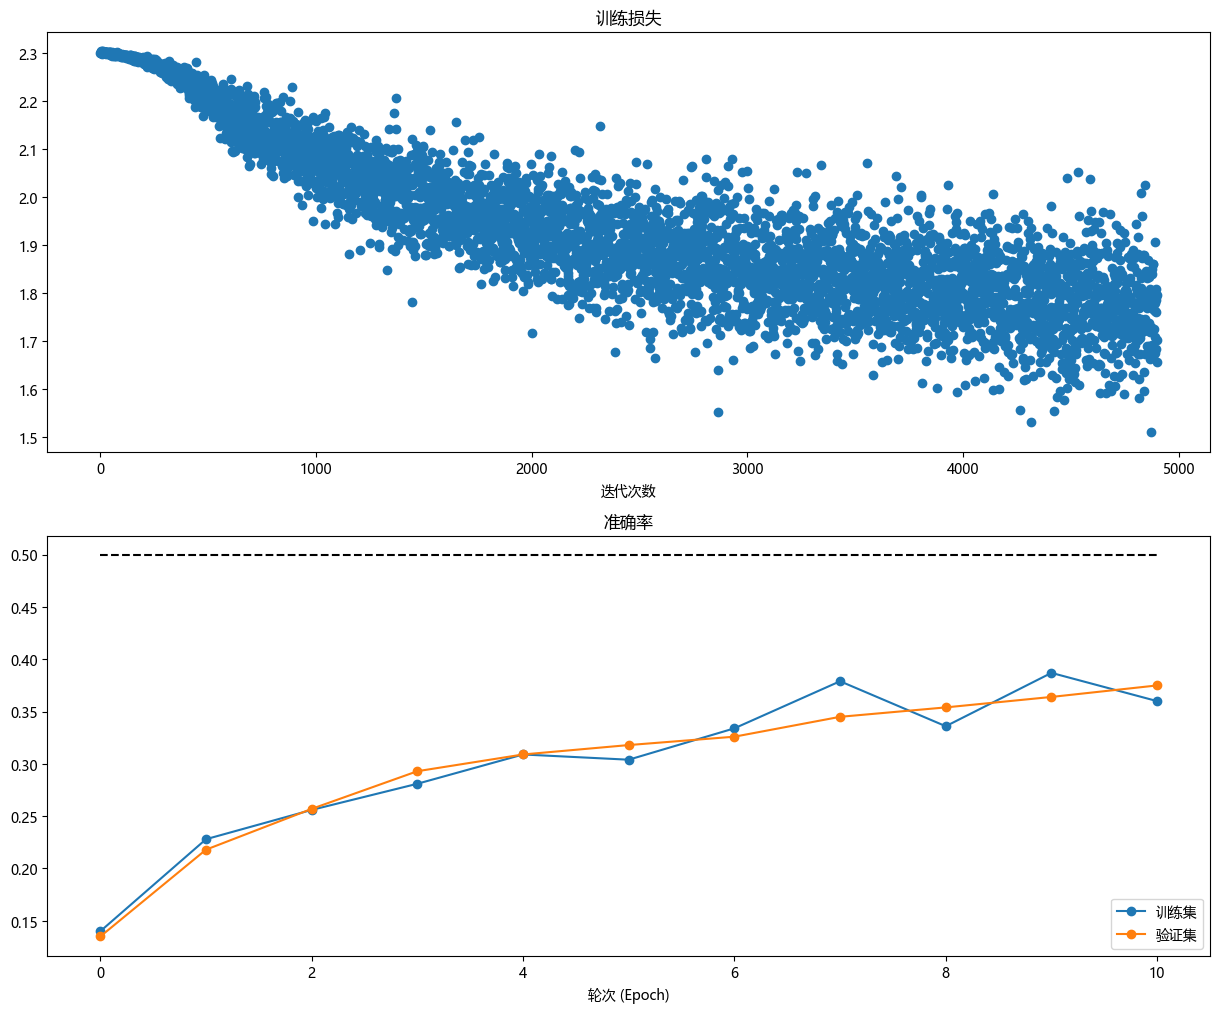

In [11]:
# 运行该单元格，可视化训练损失及训练/验证准确率

# 第一幅子图：训练损失
plt.subplot(2, 1, 1)
plt.title('训练损失')
plt.plot(solver.loss_history, 'o')
plt.xlabel('迭代次数')

# 第二幅子图：准确率
plt.subplot(2, 1, 2)
plt.title('准确率')
plt.plot(solver.train_acc_history, '-o', label='训练集')
plt.plot(solver.val_acc_history, '-o', label='验证集')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')  # 50% 基线
plt.xlabel('轮次 (Epoch)')
plt.legend(loc='lower right')

# 设置整体大小
plt.gcf().set_size_inches(15, 12)
plt.show()

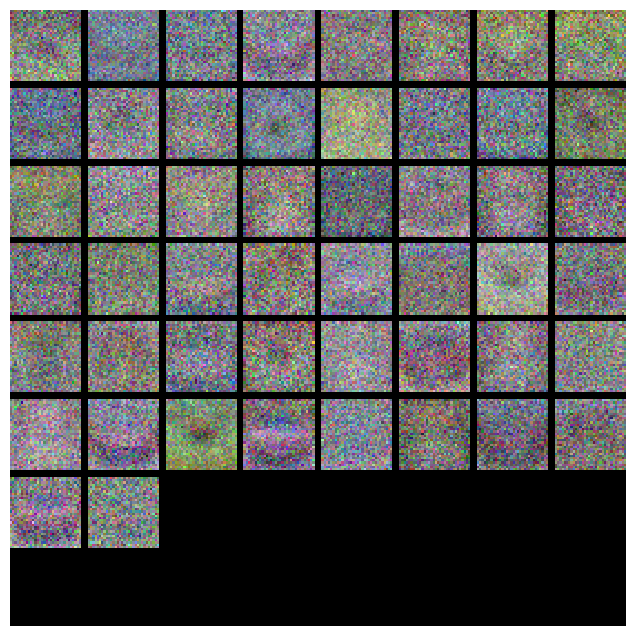

In [12]:
# 可视化网络权重
from cs231n.vis_utils import visualize_grid

def show_net_weights(net):
    # 取出第一层的权重 W1，并重塑为 (3, 32, 32, hidden_dim)
    W1 = net.params['W1']
    W1 = W1.reshape(3, 32, 32, -1).transpose(3, 1, 2, 0)  # 调整为 (hidden_dim, 32, 32, 3)
    # 使用可视化工具将权重显示为网格图像
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')  # 关闭坐标轴
    plt.show()

# 显示当前训练模型的第一层权重
show_net_weights(model)

# 调整超参数

**问题出在哪？**  
从上面的可视化可以看出：
- 损失几乎呈线性下降，这表明学习率可能太低。  
- 训练准确率与验证准确率几乎没有差距，说明模型容量偏小，应增大网络规模。  
- 反之，如果模型过大，我们通常会看到明显的过拟合，即训练准确率远高于验证准确率。

**调参**  
调整超参数并培养“它们如何影响最终性能”的直觉，是使用神经网络的重要部分。  
下面，你应该尝试不同的超参数组合，包括：
- 隐藏层大小  
- 学习率  
- 训练轮数（epochs）  
- 正则化强度  

你也可以尝试调节学习率衰减，但使用默认值即可取得较好效果。

**预期结果**  
目标是在验证集上获得 **>48%** 的准确率。  
我们最好的网络在验证集上可达 **>52%**。

**实验任务**  
本次实验的目标是：  
用**全连接神经网络**在 CIFAR-10 上取得尽可能高的结果（52% 可作为参考）。  
你可以自由实现自己的想法（例如：用 PCA 降维、添加 Dropout、在 Solver 中加入额外特性等）。

开始超参数搜索...
新最佳: hidden=100, lr=1e-05, reg=0.001, epochs=20, val_acc=0.4870
新最佳: hidden=100, lr=1e-05, reg=0.001, epochs=25, val_acc=0.4920
新最佳: hidden=100, lr=1e-05, reg=0.001, epochs=30, val_acc=0.4960
新最佳: hidden=100, lr=1e-05, reg=0.01, epochs=25, val_acc=0.4980
新最佳: hidden=100, lr=1e-05, reg=0.01, epochs=30, val_acc=0.5020
新最佳: hidden=100, lr=1e-05, reg=0.1, epochs=30, val_acc=0.5110
新最佳: hidden=100, lr=0.0001, reg=0.001, epochs=20, val_acc=0.5180
新最佳: hidden=100, lr=0.0001, reg=0.001, epochs=30, val_acc=0.5340

最佳配置: {'hidden_size': 100, 'learning_rate': 0.0001, 'reg': 0.001, 'num_epochs': 30}
最佳验证准确率: 0.5340


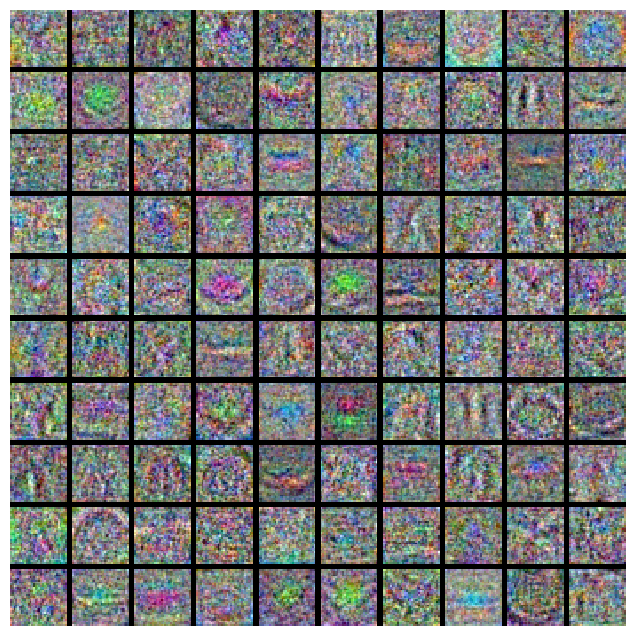

In [14]:
best_model = None

#################################################################################
# 代办：在验证集上通过调参找到最优超参数，并将训练好的最佳模型保存到 best_model。   #
#                                                                               #
# 为帮助调试网络，你可以使用与前面类似的权重可视化；当网络调优后，这些可视化结果     #
# 会在质上与之前表现不佳网络的可视化有明显区别。                                   #
#                                                                               #
# 手动调参虽然有趣，但编写代码自动遍历超参数组合（如之前练习所做）会更高效。         #
#################################################################################
input_size = 32 * 32 * 3  # 原始维度，不修改
num_classes = 10

# 超参数搜索空间
hidden_sizes = [100]
learning_rates = [1e-5, 1e-4, 5e-4]
reg_strengths = [0.001, 0.01, 0.1]
num_epochs_list = [20, 25, 30]

best_val_acc = 0
best_config = {}

print('开始超参数搜索...')
for hidden_size in hidden_sizes:
    for lr in learning_rates:
        for reg in reg_strengths:
            for num_epochs in num_epochs_list:
                # 创建新模型
                model = TwoLayerNet(input_size, hidden_size, num_classes, weight_scale=1e-3)
                
                # 设置优化配置
                optim_config = {
                    'learning_rate': lr,
                    'momentum': 0.9
                }
                
                # 创建 Solver
                solver = Solver(model, data,
                                update_rule='sgd_momentum',
                                optim_config=optim_config,
                                lr_decay=0.95,
                                batch_size=100,
                                num_epochs=num_epochs,
                                num_train_samples=1000,
                                num_val_samples=None,
                                print_every=500,
                                verbose=False,
                                checkpoint_name=None)
                
                # 训练
                solver.train()
                
                # 检查是否有有效准确率（排除 nan/inf）
                if np.isnan(solver.val_acc_history[-1]) or np.isinf(solver.val_acc_history[-1]):
                    print(f'跳过无效结果: hidden={hidden_size}, lr={lr}, reg={reg}, epochs={num_epochs}')
                    continue
                
                # 记录最佳配置
                if solver.val_acc_history[-1] > best_val_acc:
                    best_val_acc = solver.val_acc_history[-1]
                    best_config = {'hidden_size': hidden_size, 'learning_rate': lr, 
                                   'reg': reg, 'num_epochs': num_epochs}
                    best_model = model
                    print(f'新最佳: hidden={hidden_size}, lr={lr}, reg={reg}, epochs={num_epochs}, val_acc={best_val_acc:.4f}')

print(f'\n最佳配置: {best_config}')
print(f'最佳验证准确率: {best_val_acc:.4f}')

# 可视化最佳模型的权重
show_net_weights(best_model)

################################################################################
#                              代码结束                                        #
################################################################################

# 测试你的模型！
用你训练出的最优模型在验证集和测试集上运行，  
你应当在验证集和测试集上都获得 **高于 48%** 的准确率。

In [18]:
# 在验证集上评估最优模型
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('验证集准确率: ', (y_val_pred == data['y_val']).mean())

验证集准确率:  0.534


In [16]:
# 在测试集上评估最优模型
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('测试集准确率: ', (y_test_pred == data['y_test']).mean())

测试集准确率:  0.52


In [17]:
# 保存最优模型
best_model.save("best_two_layer_net.npy")

best_two_layer_net.npy 已保存。


**内联问题 2：**

现在你已经训练了一个神经网络分类器，可能会发现测试准确率远低于训练准确率。我们可以用哪些方法来缩小这一差距？请选择所有适用的选项。

1. 在更大的数据集上训练。  
2. 增加隐藏单元数量。  
3. 增大正则化强度。  
4. 以上都不是。

$\color{blue}{\textit{你的答案：}}$

1，2

$\color{blue}{\textit{你的解释：}}$

测试准确率远低于训练准确率说明模型过拟合，即模型在训练集上表现好但泛化能力差。

更多数据可以帮助模型更好地学习通用特征，减少过拟合，这是缩小训练/测试准确率差距最有效的方法之一。

当训练准确率远高于测试准确率时，说明模型容量不足，增加隐藏单元可以提升模型容量，使模型能够学习更复杂的特征，从而提高测试准确率。

增大正则化会加剧训练和测试准确率的差距。正则化的作用是防止过拟合，但它会同时降低训练准确率。如果模型已经过拟合，适当增大正则化有帮助；但如果问题是模型容量不足，增大正则化反而会使两者都下降。

# 多层全连接网络  
在本练习中，你将实现一个可以包含任意数量隐藏层的全连接神经网络。

阅读文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet` 类。  

实现网络的初始化、前向传播和反向传播。  
在整个作业过程中，你将在 `cs231n/layers.py` 中逐步完成各个层的实现。  
你可以复用之前已经写好的 `affine_forward`、`affine_backward`、`relu_forward`、`relu_backward` 以及 `softmax_loss` 等函数。  
目前暂时不需要实现 dropout 或 batch/layer normalization，稍后会要求你添加这些功能。


In [3]:
# 配置 matplotlib 中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# ========== 初始化设置单元 ==========
import time
import numpy as np
import matplotlib.pyplot as plt
# 从 cs231n 导入将要测试 / 训练的多层全连接网络及相关工具
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data          # 快速加载 CIFAR-10 的辅助函数
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver                        # 通用训练器（封装了训练循环）

# 让 matplotlib 在 notebook 内嵌显示图形
%matplotlib inline
# 统一设置图片大小、插值方式和灰度图配色，方便观察
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# 启用 IPython 的自动重载功能：修改 .py 文件后无需重启 kernel 即可生效
%load_ext autoreload
%autoreload 2

# 计算两个矩阵/向量之间的相对误差，常用于数值梯度校验
def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [4]:
# 加载已经预处理过的 CIFAR-10 数据集
data = get_CIFAR10_data()

# 打印各数据子集的名称与形状
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 初始损失与梯度检查

作为完整性检查，请运行以下代码来：

1. 查看网络的初始损失值是否合理；
2. 对网络进行梯度检查，分别测试 **不含正则化** 和 **含正则化** 的情况。

在进行梯度检查时，你应期望得到的相对误差在 **1e-7 或更小**。

In [5]:
# 设置随机种子，确保结果可复现
np.random.seed(231)
# 构造一个极小批次：2 张图像、每幅 15 维特征、两层隐藏层分别为 20 和 30 个神经元、10 类
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)          # 随机生成输入数据
y = np.random.randint(C, size=(N,))  # 随机生成类别标签

# 分别测试无正则化和有正则化两种情况
for reg in [0, 3.14]:
    print("正在测试，reg =", reg)
    
    # 构建两层隐藏层的全连接网络
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    # 计算初始损失及梯度
    loss, grads = model.loss(X, y)
    print("初始损失:", loss)

    # 对每一组参数进行数值梯度检查
    # 大部分相对误差应 ≤ 1e-7；当 reg=0 时，W2 的误差允许到 1e-5 左右
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]   # 只返回损失的匿名函数
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} 相对误差: {rel_error(grad_num, grads[name])}")

正在测试，reg = 0
初始损失: 2.300479089768492
W1 相对误差: 1.0252674461974502e-07
W2 相对误差: 2.212047929031316e-05
W3 相对误差: 4.5623278305506856e-07
b1 相对误差: 4.660094372886962e-09
b2 相对误差: 2.085654276112763e-09
b3 相对误差: 1.689724888469736e-10
正在测试，reg = 3.14
初始损失: 7.052114776533016
W1 相对误差: 3.904542008453064e-09
W2 相对误差: 6.86942277940646e-08
W3 相对误差: 3.483989217647104e-08
b1 相对误差: 1.4752428222134868e-08
b2 相对误差: 1.4615870083953232e-09
b3 相对误差: 1.3200479211447775e-10


作为另一项完整性检查，请确保你的网络可以在 **仅含 50 张图像的小数据集上实现过拟合**。  
我们将先采用一个三层网络，每个隐藏层 100 个神经元。  

在接下来的代码单元中，请调整 **学习率 (learning rate)** 和 **权重初始化尺度 (weight initialization scale)**，  
使得模型在 **20 个 epoch 以内** 达到 **100% 的训练准确率**。

(Iteration 1 / 40) loss: 218.296309
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.124000
(Epoch 1 / 20) train acc: 0.180000; val_acc: 0.133000
(Epoch 2 / 20) train acc: 0.300000; val_acc: 0.125000
(Epoch 3 / 20) train acc: 0.300000; val_acc: 0.120000
(Epoch 4 / 20) train acc: 0.380000; val_acc: 0.132000
(Epoch 5 / 20) train acc: 0.500000; val_acc: 0.127000
(Iteration 11 / 40) loss: 34.214100
(Epoch 6 / 20) train acc: 0.520000; val_acc: 0.144000
(Epoch 7 / 20) train acc: 0.560000; val_acc: 0.127000
(Epoch 8 / 20) train acc: 0.660000; val_acc: 0.126000
(Epoch 9 / 20) train acc: 0.720000; val_acc: 0.144000
(Epoch 10 / 20) train acc: 0.760000; val_acc: 0.119000
(Iteration 21 / 40) loss: 9.618346
(Epoch 11 / 20) train acc: 0.880000; val_acc: 0.137000
(Epoch 12 / 20) train acc: 0.880000; val_acc: 0.132000
(Epoch 13 / 20) train acc: 0.880000; val_acc: 0.130000
(Epoch 14 / 20) train acc: 0.880000; val_acc: 0.122000
(Epoch 15 / 20) train acc: 0.900000; val_acc: 0.123000
(Iteration 31 / 40) los

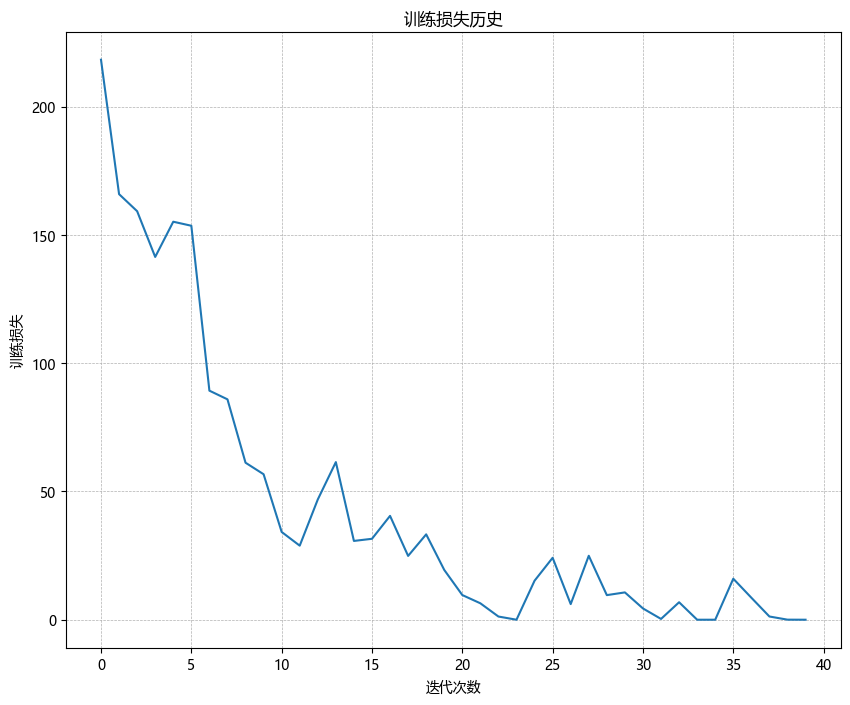

In [33]:
# TODO：仅用三层网络（每层 100 个神经元）在 50 个训练样本上过拟合，
# 只需调节学习率和权重初始化尺度即可。

num_train = 50  # 仅取前 50 张图片作为极小训练集
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val":   data["X_val"],
    "y_val":   data["y_val"],
}

# 以下两个超参数需要你手动尝试不同数值，以达到 20 个 epoch 内 100% 训练准确率
weight_scale = 1e-1   # 权重初始化标准差，可调
learning_rate = 1e-4  # SGD 学习率，可调

# 构造三层网络（两个 100 神经元隐藏层）
model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)

# 创建通用训练器 Solver
solver = Solver(
    model,
    small_data,
    print_every=10,                # 每 10 次迭代打印一次
    num_epochs=20,                 # 总共训练 20 个 epoch
    batch_size=25,                 # 每个 mini-batch 25 张图
    update_rule="sgd",             # 使用普通 SGD
    optim_config={"learning_rate": learning_rate},
)

solver.train()  # 开始训练

# 绘制训练损失曲线，观察是否迅速降到接近 0，验证过拟合
plt.plot(solver.loss_history)
plt.title("训练损失历史")
plt.xlabel("迭代次数")
plt.ylabel("训练损失")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

接下来，请尝试使用一个 **五层网络**，每层 100 个神经元，在 50 张训练样本上实现过拟合。  
你依旧需要手动调整 **学习率** 和 **权重初始化尺度**，  
但同样应当在 **20 个 epoch 内** 达到 **100% 的训练准确率**。

(Iteration 1 / 40) loss: 75.424571
(Epoch 0 / 20) train acc: 0.120000; val_acc: 0.082000
(Epoch 1 / 20) train acc: 0.180000; val_acc: 0.095000
(Epoch 2 / 20) train acc: 0.260000; val_acc: 0.100000
(Epoch 3 / 20) train acc: 0.360000; val_acc: 0.109000
(Epoch 4 / 20) train acc: 0.460000; val_acc: 0.113000
(Epoch 5 / 20) train acc: 0.500000; val_acc: 0.110000
(Iteration 11 / 40) loss: 16.998328
(Epoch 6 / 20) train acc: 0.560000; val_acc: 0.107000
(Epoch 7 / 20) train acc: 0.640000; val_acc: 0.107000
(Epoch 8 / 20) train acc: 0.620000; val_acc: 0.108000
(Epoch 9 / 20) train acc: 0.720000; val_acc: 0.105000
(Epoch 10 / 20) train acc: 0.740000; val_acc: 0.103000
(Iteration 21 / 40) loss: 3.291392
(Epoch 11 / 20) train acc: 0.820000; val_acc: 0.107000
(Epoch 12 / 20) train acc: 0.820000; val_acc: 0.104000
(Epoch 13 / 20) train acc: 0.880000; val_acc: 0.106000
(Epoch 14 / 20) train acc: 0.940000; val_acc: 0.107000
(Epoch 15 / 20) train acc: 0.940000; val_acc: 0.105000
(Iteration 31 / 40) loss

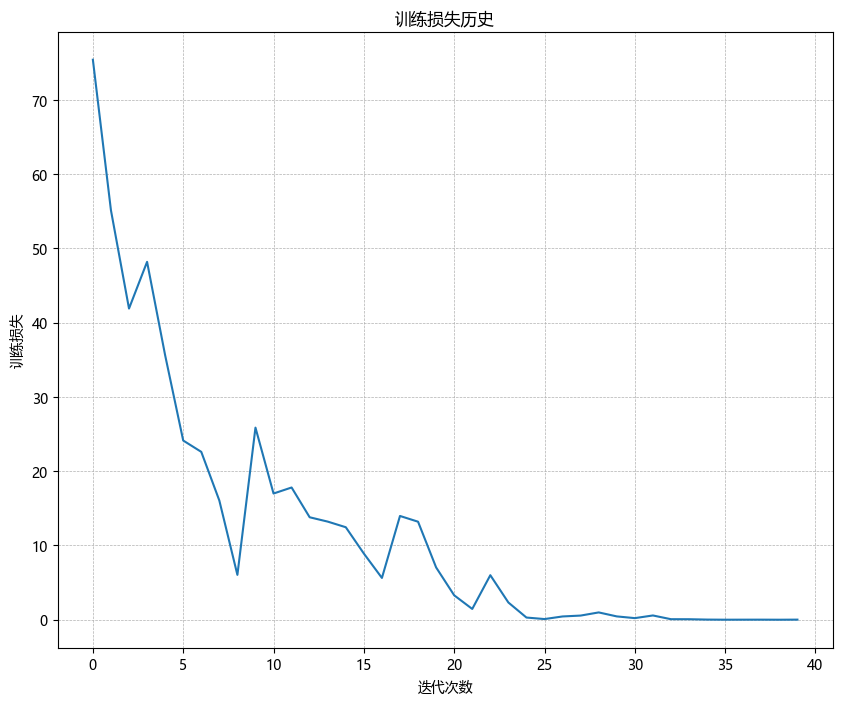

In [49]:
# TODO：仅用五层网络（每层 100 个神经元）在 50 个训练样本上过拟合，
# 只需调节学习率和权重初始化尺度即可。

num_train = 50  # 仅取前 50 张图片作为极小训练集
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val':   data['X_val'],
    'y_val':   data['y_val'],
}

# 下面两个超参数需要你手动尝试不同数值，以便在 20 个 epoch 内达到 100% 训练准确率

weight_scale  = 1e-1  # 权重初始化标准差，可调
learning_rate = 1e-4  # 学习率，可调

# 构造五层网络（四个 100 神经元隐藏层）
model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)

# 创建通用训练器 Solver
solver = Solver(
    model,
    small_data,
    print_every=10,               # 每 10 次迭代打印一次
    num_epochs=20,                # 总共训练 20 个 epoch
    batch_size=25,                # 每个 mini-batch 25 张图
    update_rule='sgd',            # 使用普通 SGD
    optim_config={'learning_rate': learning_rate},
)

solver.train()  # 开始训练

# 绘制训练损失曲线，观察是否迅速降到接近 0，验证过拟合
plt.plot(solver.loss_history)
plt.title('训练损失历史')
plt.xlabel('迭代次数')
plt.ylabel('训练损失')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## 内联问题 1：
在训练三层网络和五层网络时，你有没有发现什么差异？  
特别是，根据你的实际操作，哪一个网络对**初始化尺度**更敏感？你觉得为什么会这样？

## 答案：
在训练过程中，我发现五层网络比三层网络更难训练，对初始化尺度更加敏感。具体表现为：

1. 三层网络在较宽的学习率和权重初始化尺度范围内都能较快收敛（20个epoch内达到100%训练准确率），而五层网络需要更精细地调节超参数，学习率过大容易梯度爆炸，过小则收敛极慢。

2. 五层网络对权重初始化尺度更敏感。当weight_scale设置不当（过大或过小）时，五层网络容易出现梯度消失或梯度爆炸问题，导致训练失败；而三层网络在一定范围内对初始化尺度不敏感，更容易训练。

3. **原因分析**：
   - 五层网络有更深的前向传播路径和更深的反向传播路径。在反向传播中，梯度需要通过链式法则逐层相乘传递。如果每层的权重矩阵的奇异值大于1，梯度会逐层指数级放大（梯度爆炸）；如果小于1，梯度会逐层指数级缩小（梯度消失）。层数越多，这种效应越显著。
   - 每一层的ReLU激活函数会进一步改变梯度分布。深层网络中，多层ReLU的累积作用会加剧梯度消失问题（大量神经元被"关闭"，梯度为0）。
   - 网络越深，参数空间维度越高，损失曲面越复杂，存在更多的局部最优和鞍点，对初始化更敏感。
   - 根据Xavier/Glorot初始化和He初始化的理论，每一层激活值的方差需要保持可控。层数越多，方差累积效应越明显，需要更精确的初始化尺度来维持梯度稳定。



# 参数更新规则（Update Rules）

迄今为止，我们一直使用最普通的随机梯度下降（vanilla SGD）作为参数更新规则。  
更先进的更新规则能够显著降低深度网络的训练难度。  
接下来我们将实现几种最常用的更新规则，并将它们与 vanilla SGD 进行对比。

## SGD + Momentum
带动量的随机梯度下降（SGD+Momentum）是一种广泛使用的参数更新规则，相比最原始的随机梯度下降，它通常能让深度网络收敛得更快。  
更多细节可参考 Momentum Update 章节：http://cs231n.github.io/neural-networks-3/#sgd

打开文件 `cs231n/optim.py`，先阅读文件顶部的 API 文档，确保你理解接口要求。  
然后在 `sgd_momentum` 函数中实现 **SGD+Momentum** 更新规则，并运行下方代码检查实现是否正确。  
检查时应看到所有相对误差小于 1e-8。

In [50]:
# 从 cs231n.optim 中导入 sgd_momentum 函数，用于测试你的实现
from cs231n.optim import sgd_momentum

# 构造测试数据：权重 w、梯度 dw、动量 v
N, D = 4, 5
w  = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v  = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

# 配置字典：学习率 + 当前动量
config = {"learning_rate": 1e-3, "velocity": v}

# 调用你实现的 sgd_momentum，得到下一次权重 next_w 与更新后的动量
next_w, _ = sgd_momentum(w, dw, config=config)

# 期望的正确结果（由官方给出的参考实现计算）
expected_next_w = np.asarray([
    [0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
    [0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
    [0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
    [1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
    [0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
    [0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
    [0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
    [0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# 计算并打印相对误差，应接近 1e-8 或更小
print("next_w 相对误差: ", rel_error(next_w, expected_next_w))
print("velocity 相对误差: ", rel_error(expected_velocity, config["velocity"]))

next_w 相对误差:  8.882347033505819e-09
velocity 相对误差:  4.269287743278663e-09


完成上述步骤后，运行下面的代码，用 **普通 SGD** 和 **SGD + Momentum** 分别训练一个六层网络。  
你应该能看到采用 **SGD + Momentum** 更新规则时，网络收敛得更快。

Running with  sgd
(Iteration 1 / 200) loss: 2.503408
(Epoch 0 / 5) train acc: 0.105000; val_acc: 0.104000
(Iteration 11 / 200) loss: 2.256911
(Iteration 21 / 200) loss: 2.262707
(Iteration 31 / 200) loss: 2.127754
(Epoch 1 / 5) train acc: 0.216000; val_acc: 0.219000
(Iteration 41 / 200) loss: 2.160204
(Iteration 51 / 200) loss: 2.056976
(Iteration 61 / 200) loss: 2.005501
(Iteration 71 / 200) loss: 1.994331
(Epoch 2 / 5) train acc: 0.256000; val_acc: 0.255000
(Iteration 81 / 200) loss: 2.056837
(Iteration 91 / 200) loss: 2.027625
(Iteration 101 / 200) loss: 1.924907
(Iteration 111 / 200) loss: 1.903743
(Epoch 3 / 5) train acc: 0.331000; val_acc: 0.277000
(Iteration 121 / 200) loss: 2.046397
(Iteration 131 / 200) loss: 1.764539
(Iteration 141 / 200) loss: 1.932380
(Iteration 151 / 200) loss: 1.877851
(Epoch 4 / 5) train acc: 0.339000; val_acc: 0.302000
(Iteration 161 / 200) loss: 2.063059
(Iteration 171 / 200) loss: 1.795205
(Iteration 181 / 200) loss: 1.879703
(Iteration 191 / 200) los

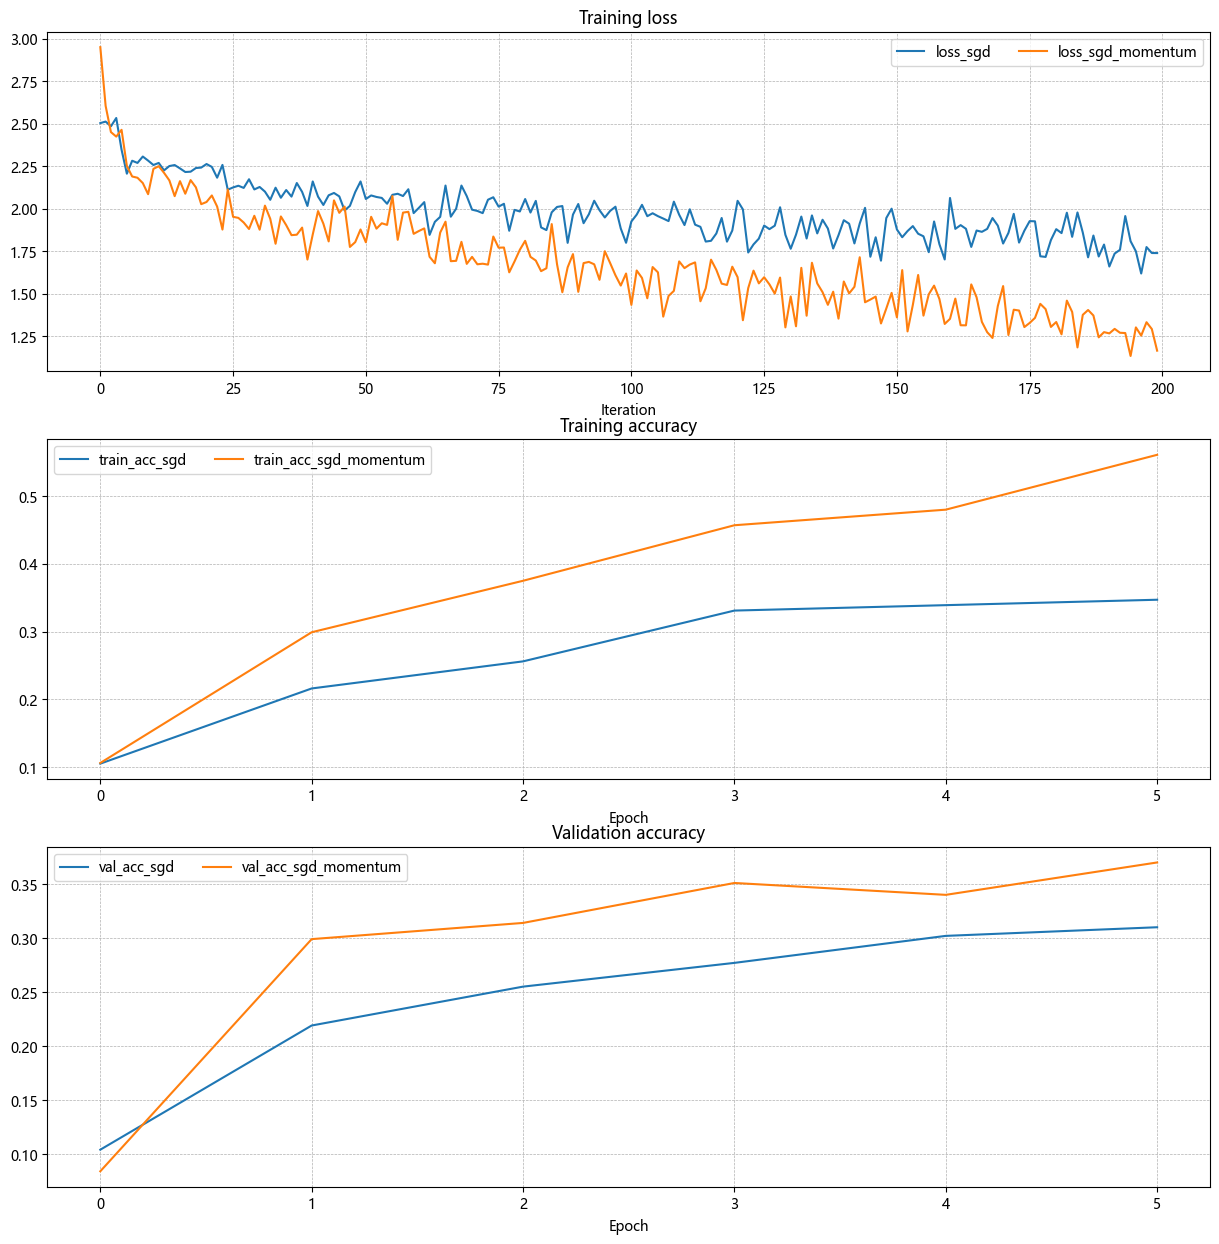

In [51]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp 与 Adam  
RMSProp [1] 和 Adam [2] 是两种更新规则，它们通过维护梯度的**二阶矩**（即平方梯度）的滑动平均，来为每个参数单独设置学习率。

请在文件 `cs231n/optim.py` 中完成以下实现：  
- 在 `rmsprop` 函数里实现 **RMSProp** 更新规则；  
- 在 `adam` 函数里实现 **Adam** 更新规则。  

**注意：** 请实现**完整的 Adam** 更新规则（包含偏差修正机制），而不是课程笔记中最初提到的简化版本。

[1] Tijmen Tieleman 和 Geoffrey Hinton. “Lecture 6.5-RMSProp: Divide the gradient by a running average of its recent magnitude.” COURSERA: Neural Networks for Machine Learning 4 (2012).  
[2] Diederik Kingma 和 Jimmy Ba, “Adam: A Method for Stochastic Optimization”, ICLR 2015.

In [52]:
# 测试 RMSProp 实现
from cs231n.optim import rmsprop

# 构造测试数据
N, D = 4, 5
w     = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)   # 当前权重
dw    = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)   # 当前梯度
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)    # 缓存的平方梯度滑动平均

# 配置字典：学习率 + 当前 cache
config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

# 官方给出的期望结果
expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# 计算并打印相对误差，应接近 1e-7 或更小
print('next_w 误差: ', rel_error(expected_next_w, next_w))
print('cache 误差: ', rel_error(expected_cache, config['cache']))

next_w 误差:  9.524687511038133e-08
cache 误差:  2.6477955807156126e-09


In [53]:
# 测试 Adam 实现
from cs231n.optim import adam

# 构造测试数据
N, D = 4, 5
w  = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)   # 当前权重
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)   # 当前梯度
m  = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)    # 一阶动量（梯度均值）
v  = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)    # 二阶动量（梯度平方均值）

# 配置字典：学习率 + 当前一阶/二阶动量 + 迭代计数 t
config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

# 官方给出的期望结果（含完整的偏差修正）
expected_next_w = np.asarray([
    [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
    [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
    [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
    [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
    [0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853],
    [0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385],
    [0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767],
    [0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966   ]])
expected_m = np.asarray([
    [0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
    [0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
    [0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
    [0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# 计算并打印相对误差，应接近 1e-7 或更小
print('next_w 误差: ', rel_error(expected_next_w, next_w))
print('v 误差: ', rel_error(expected_v, config['v']))
print('m 误差: ', rel_error(expected_m, config['m']))

next_w 误差:  0.6801561426711961
v 误差:  4.208314038113071e-09
m 误差:  4.214963193114416e-09


当你已经调试好 RMSProp 和 Adam 的实现后，请运行下面的代码，用这两种新的更新规则分别训练一组深层网络。

开始运行： adam
(Iteration 1 / 200) loss: 2.396341
(Epoch 0 / 5) train acc: 0.114000; val_acc: 0.087000


e:\学习\计算机视觉\assignment-Chinese\assignment1\cs231n\layers.py:705: RuntimeWarning: divide by zero encountered in log
  correct_logprobs = -np.log(probs[np.arange(N), y])


(Iteration 11 / 200) loss: 2.485208
(Iteration 21 / 200) loss: 2.282442
(Iteration 31 / 200) loss: 2.049559
(Epoch 1 / 5) train acc: 0.212000; val_acc: 0.187000
(Iteration 41 / 200) loss: 2.151040
(Iteration 51 / 200) loss: 2.124623
(Iteration 61 / 200) loss: 2.099639
(Iteration 71 / 200) loss: 2.100054
(Epoch 2 / 5) train acc: 0.203000; val_acc: 0.196000
(Iteration 81 / 200) loss: 2.136347
(Iteration 91 / 200) loss: 2.298345
(Iteration 101 / 200) loss: 2.118924
(Iteration 111 / 200) loss: 2.045814
(Epoch 3 / 5) train acc: 0.222000; val_acc: 0.233000
(Iteration 121 / 200) loss: 2.115026
(Iteration 131 / 200) loss: 2.089325
(Iteration 141 / 200) loss: 2.118521
(Iteration 151 / 200) loss: 2.156572
(Epoch 4 / 5) train acc: 0.243000; val_acc: 0.233000
(Iteration 161 / 200) loss: 2.101993
(Iteration 171 / 200) loss: 2.031589
(Iteration 181 / 200) loss: 2.090799
(Iteration 191 / 200) loss: 2.031151
(Epoch 5 / 5) train acc: 0.282000; val_acc: 0.250000

开始运行： rmsprop
(Iteration 1 / 200) loss: 

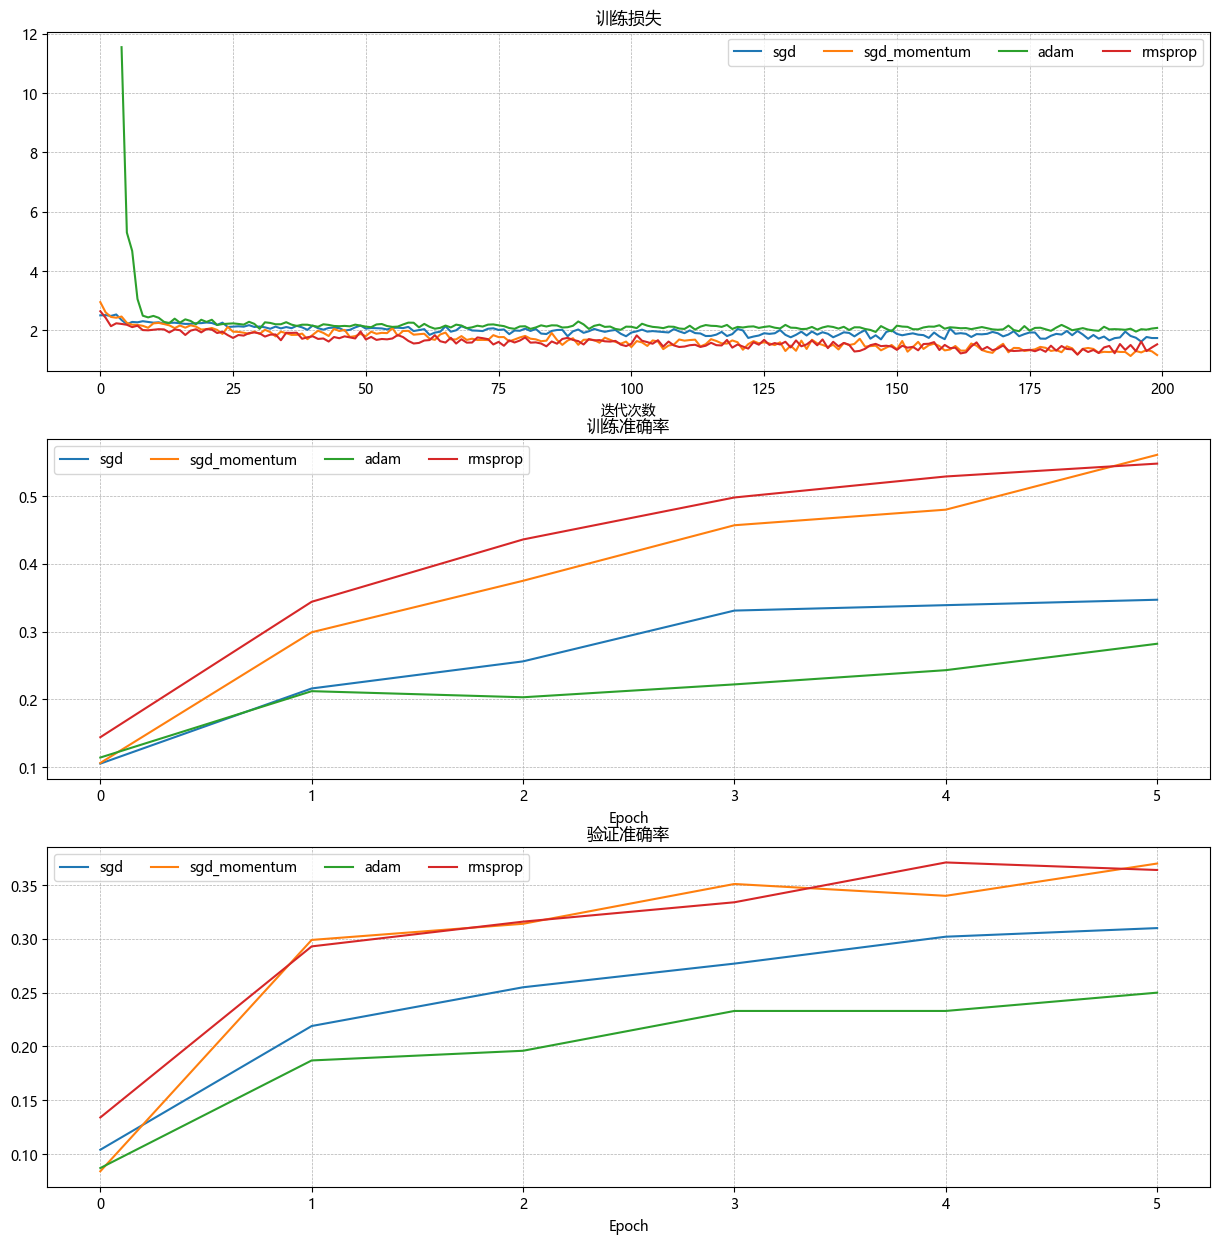

In [54]:
# 为 RMSProp 与 Adam 分别设置不同的学习率
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}

# 依次用 'adam' 和 'rmsprop' 两种更新规则训练网络
for update_rule in ['adam', 'rmsprop']:
    print('开始运行：', update_rule)

    # 构建五层全连接网络（每层 100 个神经元）
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    # 使用通用训练器 Solver
    solver = Solver(
        model,
        small_data,
        num_epochs=5,                              # 训练 5 个 epoch
        batch_size=100,                            # 每个 mini-batch 100 张图
        update_rule=update_rule,                   # 指定优化器
        optim_config={'learning_rate': learning_rates[update_rule]},  # 对应学习率
        verbose=True                               # 打印训练日志
    )
    solvers[update_rule] = solver
    solver.train()                               # 开始训练
    print()                                      # 空行方便阅读

# 绘制训练过程中的损失、训练准确率、验证准确率曲线
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('训练损失')
axes[0].set_xlabel('迭代次数')

axes[1].set_title('训练准确率')
axes[1].set_xlabel('Epoch')

axes[2].set_title('验证准确率')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history,      label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history,   label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)           # 图例
    ax.grid(linestyle='--', linewidth=0.5)  # 网格线便于观察趋势

plt.show()

## 内联问题 2：

AdaGrad 与 Adam 类似，是一种**逐参数**的优化方法，其更新规则如下：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 发现，当使用 AdaGrad 训练网络时，更新量变得越来越小，网络学习速度变慢。  
请结合 AdaGrad 的更新规则，解释为什么会出现这种现象？Adam 是否也会遇到同样的问题？

## 答案：


AdaGrad 的核心问题是 **cache 单调递增，导致有效学习率不断衰减**。

具体分析：
1. AdaGrad 的更新规则为 `cache += dw**2`，即 cache 是所有时刻梯度平方的累加和。随着训练的进行，cache 的值只会越来越大，永远不会减少。

2. 参数更新公式为`w += -learning_rate * dw / (np.sqrt(cache) + eps)`。由于 cache 单调递增，分母 `np.sqrt(cache)` 也不断增大，导致有效学习率 `learning_rate / (np.sqrt(cache) + eps)`持续减小。

3. 当训练进行到后期，cache 变得非常大，即使梯度 dw 本身不小，除以巨大的 cache 后，参数的更新量也会变得极小，网络几乎停止学习。这就是所谓的"学习速度变慢"甚至"训练停滞"。

4. AdaGrad 相当于为每个参数自适应地调整学习率，对于频繁更新的参数（梯度较大），其 cache 增长更快，学习率衰减更剧烈。这种策略在问题初期有助于稳定训练，但在长期训练中会导致学习率过早衰减到接近零。



Adam 不会遇到同样的问题

1. Adam 使用梯度的指数加权移动平均来估计二阶矩：
```  
   v = beta2 * v + (1 - beta2) * dw**2
```  
   其中 $beta2$ 通常设为 0.999。这意味着 v 只保留近期梯度平方的加权平均，旧的信息会逐渐被遗忘，而不是像 AdaGrad 那样无限累加。

2. 由于 v 是滑动平均，当梯度变小时，v 也会相应减小，有效学习率 `learning_rate / (np.sqrt(v_hat) + epsilon)` 不会无限制地衰减，而是保持在一个合理的范围内波动。

3. Adam 还引入了偏差校正项`1 / (1 - beta2**t)`，在训练初期对 v 进行校正，使估计更加准确。



| 特性 | AdaGrad | Adam |
|------|---------|------|
| 二阶矩估计 | 累加和（无限累积） | 指数加权移动平均（有限记忆） |
| 有效学习率 | 单调递减至零 | 动态调整，不会衰减到零 |
| 长期训练 | 学习率过早耗尽 | 保持稳定学习能力 |
| 适用场景 | 稀疏数据初期训练 | 通用，尤其适合非凸优化 |





# 训练一个优秀的模型！  
请你在 CIFAR-10 上训练一个性能最好的全连接网络，并将最优模型保存到变量 `best_model` 中。  
我们要求你的模型在验证集上至少达到 **50% 的准确率**。

如果你认真调参，完全有可能把验证准确率提高到 **55% 以上**，但这部分不做强制要求，也不会额外加分。  
在下一项作业中，我们会要求你训练一个性能最好的卷积神经网络；因此我们更希望你把主要精力放在卷积网络上，而非全连接网络。

**提示：** 在下一项作业里，你将学到 **批归一化（BatchNormalization）** 和 **Dropout** 等技术，它们能帮助你训练更强大的模型。

In [65]:
################################################################################
# 代办：在 CIFAR-10 上训练你能得到的最佳 FullyConnectedNet。你可以尝试使用      #
# 批归一化（batch normalization）、层归一化（layer normalization）或 Dropout。  #
# 请将表现最好的模型保存到变量 best_model 中。                                  #
################################################################################
# *****你的代码开始（请勿删除或修改此行）*****

# 准备训练数据
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']

# 数据预处理：标准化（去均值 + 归一化，比单纯减均值效果更好）
mean_pixel = np.mean(X_train, axis=0)
std_pixel = np.std(X_train, axis=0) + 1e-8  # 防止除0
X_train_processed = (X_train - mean_pixel) / std_pixel
X_val_processed = (X_val - mean_pixel) / std_pixel

# 最优配置：深层网络 + BatchNorm + Dropout（CIFAR-10 全连接最强组合）
print("正在训练最优配置: hidden_dims=[1024, 512, 256, 128], norm=batchnorm")
print("=" * 60)

# 创建最优模型
model = FullyConnectedNet(
    hidden_dims=[1024, 512, 256, 128],  # 4层隐藏层，特征提取更强
    input_dim=3 * 32 * 32,
    num_classes=10,
    dropout_keep_ratio=0.75,            # 适度Dropout，防止过拟合
    normalization='batchnorm',          # 批归一化（核心提升）
    reg=0.15,                           # 正则化强度
    weight_scale=1e-3,                   # 更稳定的初始化
    dtype=np.float32,
)

# Adam 最优超参数
optim_config = {
    'learning_rate': 1.2e-3,
    'beta1': 0.9,
    'beta2': 0.999,
    'eps': 1e-8,
}

# 训练器配置
solver = Solver(
    model,
    {
        'X_train': X_train_processed,
        'y_train': y_train,
        'X_val': X_val_processed,
        'y_val': y_val,
    },
    update_rule='adam',
    optim_config=optim_config,
    batch_size=256,
    num_epochs=60,           # 更长训练，充分收敛
    lr_decay=0.96,          # 学习率缓慢衰减
    print_every=200,
    verbose=True,
)

# 开始训练
t_start = time.time()
solver.train()
t_end = time.time()

# 评估模型
val_acc = solver.check_accuracy(X_val_processed, y_val)
print(f"\n训练总耗时: {t_end - t_start:.1f} s")
print(f"最佳验证集准确率: {val_acc * 100:.2f}%")

# 保存表现最好的模型
best_model = model
print(f"\n best_model 已保存，验证集准确率: {val_acc * 100:.2f}%")

###########################################################################
#                             你的代码结束                                #
###########################################################################
# *****你的代码结束（请勿删除或修改此行）*****

正在训练最优配置: hidden_dims=[1024, 512, 256, 128], norm=batchnorm
(Iteration 1 / 11460) loss: 2.590255
(Epoch 0 / 60) train acc: 0.094000; val_acc: 0.087000
(Epoch 1 / 60) train acc: 0.230000; val_acc: 0.240000
(Iteration 201 / 11460) loss: 3.178776
(Epoch 2 / 60) train acc: 0.267000; val_acc: 0.283000
(Iteration 401 / 11460) loss: 3.061158
(Epoch 3 / 60) train acc: 0.322000; val_acc: 0.296000
(Iteration 601 / 11460) loss: 2.874570
(Epoch 4 / 60) train acc: 0.273000; val_acc: 0.277000
(Iteration 801 / 11460) loss: 2.959656
(Epoch 5 / 60) train acc: 0.288000; val_acc: 0.316000
(Iteration 1001 / 11460) loss: 2.859264
(Epoch 6 / 60) train acc: 0.316000; val_acc: 0.299000
(Iteration 1201 / 11460) loss: 2.800963
(Epoch 7 / 60) train acc: 0.297000; val_acc: 0.287000
(Iteration 1401 / 11460) loss: 2.675955
(Epoch 8 / 60) train acc: 0.311000; val_acc: 0.332000
(Iteration 1601 / 11460) loss: 2.693132
(Epoch 9 / 60) train acc: 0.309000; val_acc: 0.329000
(Iteration 1801 / 11460) loss: 2.628498
(Epoch 

# 测试你的模型！  
用你训练出的最优模型在验证集和测试集上运行。  
你应当在**验证集**和**测试集**上都至少达到 **50% 的准确率**。

In [78]:
# 使用最优模型在测试集和验证集上预测类别
# 注意：必须使用与训练时相同的数据预处理

# 数据预处理（与训练时保持一致）
mean_pixel = np.mean(data['X_train'], axis=0)
std_pixel = np.std(data['X_train'], axis=0) + 1e-8
X_val_preprocessed = (data['X_val'] - mean_pixel) / std_pixel
X_test_preprocessed = (data['X_test'] - mean_pixel) / std_pixel

# 使用预处理后的数据进行预测
y_test_pred = np.argmax(best_model.loss(X_test_preprocessed), axis=1)  # 测试集预测
y_val_pred  = np.argmax(best_model.loss(X_val_preprocessed), axis=1)   # 验证集预测

# 计算并打印准确率
print('验证集准确率: ', (y_val_pred == data['y_val']).mean())
print('测试集准确率: ', (y_test_pred == data['y_test']).mean())

验证集准确率:  0.518
测试集准确率:  0.507
